# 07 -- Joint Hurdle BiLSTM v4 + expanded temporal early stopping

Текущий лучший LSTM run команды.

**Public RMSLE: 1.6506631932**

Сабмит:

```text
lstm_hurdle_v4_expanded_es_3seed.csv
```

Предыдущий public-best этой же архитектуры:

```text
1.6509102971 -> 1.6506631932
```

Абсолютный gain:

```text
0.0002471039 RMSLE
```

Этот notebook отвечает на конкретный вопрос старого v4 run: была ли эпоха `6` реальным optimum или просто искусственным пределом обучения.

В старой версии CV разрешала максимум 6 эпох. Здесь training horizon расширен до 30 эпох, а реальное число эпох выбирается temporal CV + early stopping.

В final train используются **три независимых seed** -- `42`, `143`, `2026`. Их predictions усредняются в `log1p`-пространстве.

LightGBM-oracle в этом run выключен и на итоговый результат не влияет.

## Вся логика notebook сверху вниз

Notebook можно понимать как десять последовательных этапов.

```text
1. data/lstm artifacts
        |
        v
2. 90-day sequence + static snapshot
        |
        v
3. feature engineering
        |
        +-------------------------+
        |                         |
        v                         v
sequence 53/day            short summary 93
        |                         |
     BiLSTM                     MLP
        |                         |
        +-------------+-----------+
                      |
                 static 235
                      |
                     MLP
                      |
                      v
                   fusion 96
                      |
          +-----------+-----------+
          |           |           |
        gate       positive     direct
          |           |           |
          +---- hurdle_log        |
                 |                |
                 +-------+--------+
                         |
                    learned blend
                         |
                      pred_log
                         |
                         v
4. loss в log1p-space
                         |
                         v
5. temporal CV: Nov / Dec / Jan
                         |
                         v
6. early stopping внутри каждого fold
                         |
                         v
7. BEST_EPOCH по mean RMSLE common epochs
                         |
                         v
8. заново train на ВСЕХ labeled data
       seed 42 / seed 143 / seed 2026
                         |
                         v
9. mean трех pred_log
                         |
                       expm1
                         |
                         v
10. submission
```

### Что именно выбирает CV

CV **не выбирает финальные веса**.

Каждый CV fold создает отдельную LSTM с нуля и обучает ее только для оценки качества во времени. После CV эти веса не становятся final model.

Из CV нам нужен прежде всего:

```text
BEST_EPOCH = 10
```

После этого создаются новые модели и обучаются на всех labeled cutoff ровно 10 эпох.

### Почему три seed

Одна и та же нейросеть при одинаковых гиперпараметрах все равно получает немного разные веса из-за:

- случайной инициализации;
- shuffle батчей;
- dropout;
- численной стохастики backend.

Поэтому final train делает три независимые копии:

```text
seed 42
seed 143
seed 2026
```

Это не три разные архитектуры и не три CV fold. Это три независимых обучения **одной final архитектуры на одних и тех же всех данных**.

Финальный ensemble:

$$
\hat z =
\frac{
\hat z_{42} + \hat z_{143} + \hat z_{2026}
}{3},
$$

где $\hat z=\log(1+\hat y)$.

Только после усреднения:

$$
\hat y = \exp(\hat z)-1.
$$

Такое усреднение снижает variance конкретной случайной инициализации и соответствует пространству, в котором оптимизируется RMSLE.

### Что изменено относительно старой Hurdle BiLSTM

Старая модель имела две полностью независимые сети:

```text
classifier -> P(GMV > 0)
regressor  -> positive_log
```

В Joint Hurdle v4 один дорогой encoder общий, а поверх него стоят три дешевые головы:

```text
shared encoder -> gate / positive / direct
```

Главный loss сразу оптимизирует итоговый `pred_log`.

In [1]:
from pathlib import Path
import hashlib
import json
import math
import random
import shutil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.utils.data import ConcatDataset, DataLoader, Dataset


def find_project_root():
    for path in [Path.cwd(), *Path.cwd().parents]:
        if (path / "data" / "lstm" / "meta.json").exists():
            return path
    raise FileNotFoundError(
        "Не найден data/lstm/meta.json. Сначала запустите обновленный 06_LSTM_Data_Preparation.ipynb."
    )


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "lstm"
MODEL_DIR = PROJECT_ROOT / "models" / "lstm_hurdle_v4_expanded_es"
REFERENCE_MODEL_DIR = PROJECT_ROOT / "models" / "lstm_hurdle_v4_robust"
SUBMISSION_DIR = PROJECT_ROOT / "submissions"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)

with open(DATA_DIR / "meta.json", encoding="utf-8") as f:
    META = json.load(f)

if META.get("format_version") != 2:
    raise RuntimeError(
        "LSTM v4 ожидает data format v2. Перезапустите обновленный 06_LSTM_Data_Preparation.ipynb."
    )

LABELED_CUTOFFS = META["labeled_cutoffs"]
INFERENCE_CUTOFF = META["inference_cutoff"]
BASE_SEQUENCE_FEATURES = META["base_sequence_features"]
CALENDAR_FEATURES = META["calendar_sequence_features"]
RAW_STATIC_FEATURES = META["static_features"]
RAW_STATIC_LOG_FEATURES = META["static_log_copy_features"]
EXTRA_STATIC_FEATURES = set(META.get("extra_static_features", []))
SEQ_LEN = int(META["seq_len"])
N_USERS = int(META["user_count"])

BASE_INDEX = {name: i for i, name in enumerate(BASE_SEQUENCE_FEATURES)}

# Флаги меняю по одному после baseline run.
USE_USER_EMBEDDING = False
USER_EMBED_DIM = 4
USE_CONV_STEM = False

USE_ABSOLUTE_TIME = True
USE_FUTURE_CALENDAR_STATIC = False
USE_CUTOFF_SEASONAL_STATIC = False

BATCH_SIZE = 768
MAX_CV_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 8
EARLY_STOPPING_MIN_DELTA = 1e-4
MIN_CV_EPOCHS_BEFORE_STOP = 8
N_CV_FOLDS = 3
LR = 3.5e-4
EMBED_LR = 1.0e-4
WEIGHT_DECAY = 1.2e-3
EMBED_WEIGHT_DECAY = 8e-3
RANDOM_STATE = 42
FINAL_SEEDS = [42, 143, 2026]

AUX_GATE_WEIGHT = 0.03
AUX_POS_WEIGHT = 0.10
AUX_DIRECT_WEIGHT = 0.05

REFERENCE_MEAN_CV_RMSLE = 1.715288
REFERENCE_JAN_HOLDOUT_RMSLE = 1.675888
AUTO_SKIP_FINAL_IF_WEAK = True
MAX_MEAN_CV_DEGRADATION_FOR_FINAL = 0.003
MAX_JAN_DEGRADATION_FOR_FINAL = 0.006
FORCE_FINAL_TRAIN = False

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
NUM_WORKERS = 4 if DEVICE.type == "cuda" else 0
USE_AMP = DEVICE.type == "cuda"


def set_seed(seed=RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def choose_static_features():
    selected = []
    for name in RAW_STATIC_FEATURES:
        if name not in EXTRA_STATIC_FEATURES:
            selected.append(name)
            continue

        if name == "cutoff_time_years" and USE_ABSOLUTE_TIME:
            selected.append(name)
        elif name.startswith("forecast_") and USE_FUTURE_CALENDAR_STATIC:
            selected.append(name)
        elif (
            name.startswith("cutoff_")
            and name != "cutoff_time_years"
            and USE_CUTOFF_SEASONAL_STATIC
        ):
            selected.append(name)
    return selected


STATIC_FEATURES = choose_static_features()
STATIC_INDICES = np.array(
    [RAW_STATIC_FEATURES.index(name) for name in STATIC_FEATURES],
    dtype=np.int64,
)
STATIC_LOG_FEATURES = [name for name in RAW_STATIC_LOG_FEATURES if name in STATIC_FEATURES]
STATIC_LOG_INDICES = [STATIC_FEATURES.index(name) for name in STATIC_LOG_FEATURES]

set_seed()
print("device:", DEVICE)
print("AMP:", USE_AMP)
print("labeled cutoffs:", LABELED_CUTOFFS)
print("CV validation cutoffs:", LABELED_CUTOFFS[-N_CV_FOLDS:])
print("inference:", INFERENCE_CUTOFF)
print("users:", N_USERS)
print("static features:", len(STATIC_FEATURES), "/", len(RAW_STATIC_FEATURES))
print("user embedding:", USE_USER_EMBEDDING)
print("future calendar static:", USE_FUTURE_CALENDAR_STATIC)
print("max CV epochs:", MAX_CV_EPOCHS)
print("early stopping patience:", EARLY_STOPPING_PATIENCE)
print("early stopping min delta:", EARLY_STOPPING_MIN_DELTA)
print("minimum epochs before stop:", MIN_CV_EPOCHS_BEFORE_STOP)
print("model dir:", MODEL_DIR)

device: mps
AMP: False
labeled cutoffs: ['2025-04-19', '2025-05-19', '2025-06-18', '2025-07-18', '2025-08-17', '2025-09-16', '2025-10-16', '2025-11-15', '2025-12-15', '2026-01-14']
CV validation cutoffs: ['2025-11-15', '2025-12-15', '2026-01-14']
inference: 2026-02-13
users: 250000
static features: 92 / 103
user embedding: False
future calendar static: False
max CV epochs: 30
early stopping patience: 8
early stopping min delta: 0.0001
minimum epochs before stop: 8
model dir: /Users/pinta/Dev/E-CUP-2026/models/lstm_hurdle_v4_expanded_es


## 1. Dataset и variable-length history

На диске уже лежат artifacts из `06_LSTM_Data_Preparation.ipynb`.

Для каждого `user_id x cutoff` notebook получает:

- `sequence` -- последние 90 дней;
- `static` -- snapshot-признаки пользователя на cutoff;
- `user_index`;
- `user_known`;
- `history_length`;
- `target` -- GMV следующих 30 дней для labeled cutoff.

### Зачем нужен `history_length`

Не у каждого пользователя есть настоящая история длиной 90 дней.

Если пользователь появился 20 дней назад, первые 70 позиций sequence -- padding, а не реальные дни с нулевой активностью.

`history_length` позволяет:

- отличить padding от реального нуля;
- compact'нуть историю;
- передать в `pack_padded_sequence` только реальные timestep;
- не учитывать padding в mean/max/attention pooling.

`user_id` embedding в текущем final run выключен, но dataset оставляет `user_index/user_known`, чтобы архитектура могла поддерживать эту ablation без изменения формата данных.

In [2]:
def known_user_mask_from_cutoffs(cutoffs):
    mask = np.zeros(N_USERS, dtype=np.bool_)
    for cutoff in cutoffs:
        idx = np.load(DATA_DIR / cutoff / "user_index.npy", mmap_mode="r")
        mask[np.asarray(idx, dtype=np.int64)] = True
    return mask


class HybridDataset(Dataset):
    def __init__(self, cutoff, with_target=True, known_user_mask=None):
        path = DATA_DIR / cutoff
        self.X = np.load(path / "X.npy", mmap_mode="r")
        self.static = np.load(path / "static.npy", mmap_mode="r")
        self.calendar = np.load(path / "calendar.npy", mmap_mode="r").astype(np.float32)
        self.users = np.load(path / "user_id.npy", mmap_mode="r")
        self.user_index = np.load(path / "user_index.npy", mmap_mode="r")
        self.history_length = np.load(path / "history_length.npy", mmap_mode="r")
        self.y = np.load(path / "y.npy", mmap_mode="r") if with_target else None
        self.known_user_mask = known_user_mask

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        sequence = np.concatenate([
            np.asarray(self.X[i], dtype=np.float32),
            self.calendar,
        ], axis=1)

        user_index = int(self.user_index[i])
        user_known = True if self.known_user_mask is None else bool(self.known_user_mask[user_index])

        raw_static = np.asarray(self.static[i], dtype=np.float32)
        static = raw_static[STATIC_INDICES]

        result = (
            torch.from_numpy(sequence),
            torch.from_numpy(static),
            torch.tensor(user_index, dtype=torch.long),
            torch.tensor(user_known, dtype=torch.bool),
            torch.tensor(int(self.history_length[i]), dtype=torch.long),
        )

        if self.y is None:
            return result

        return (*result, torch.tensor(float(self.y[i]), dtype=torch.float32))


def make_loader(
    cutoffs,
    shuffle=False,
    with_target=True,
    batch_size=BATCH_SIZE,
    known_user_mask=None,
):
    if isinstance(cutoffs, str):
        cutoffs = [cutoffs]

    dataset = ConcatDataset([
        HybridDataset(
            cutoff,
            with_target=with_target,
            known_user_mask=known_user_mask,
        )
        for cutoff in cutoffs
    ])

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=DEVICE.type == "cuda",
        persistent_workers=NUM_WORKERS > 0,
        drop_last=False,
    )

## 2. Feature engineering

Модель одновременно получает три представления одного пользователя:

```text
A. sequence -- что происходило по дням
B. short summary -- простые агрегаты последних окон
C. static -- длинный snapshot из Prepared_data
```

### A. Sequence -- 53 признака на каждый из 90 дней

С диска приходят 19:

- 13 базовых behavioral/GMV каналов;
- 6 календарных sin/cos каналов.

Еще 34 считаются на батче:

- mask реальной истории;
- relative position и distance to cutoff;
- event flags;
- conversion ratios;
- rolling mean 3/7/14/30;
- rolling activity rate 3/7/14/30;
- first differences.

Rolling и differences используют только историю до cutoff.

Итого:

```text
batch x 90 x 53
```

### B. Short summary -- 93 признака

BiLSTM теоретически может сама выучить агрегаты типа "сколько покупок было за последние 7 дней", но заставлять recurrent encoder заново изобретать такие простые статистики невыгодно.

Поэтому отдельно считаются:

- суммы за 1/3/7/14/30/60/90;
- activity rate;
- days since last event;
- recent minus previous;
- три 30-day bucket;
- purchase periodicity;
- относительная длина истории.

Эта ветка дает модели явные recency/frequency сигналы.

### C. Static -- 235 после preprocessing

В final run:

```text
92 raw static
+ 51 log1p copies heavy-tail признаков
+ 92 missing masks
= 235
```

Future calendar, cutoff-seasonal static, user embedding и conv stem выключены.

In [3]:
def history_mask_from_lengths(lengths, steps=SEQ_LEN):
    positions = torch.arange(steps, device=lengths.device).unsqueeze(0)
    starts = steps - lengths.unsqueeze(1)
    return positions >= starts


def causal_masked_mean(values, valid_mask, window):
    values = values * valid_mask
    num = F.avg_pool1d(
        F.pad(values.unsqueeze(1), (window - 1, 0)),
        window,
        stride=1,
    ).squeeze(1) * window
    den = F.avg_pool1d(
        F.pad(valid_mask.unsqueeze(1), (window - 1, 0)),
        window,
        stride=1,
    ).squeeze(1) * window
    return num / den.clamp_min(1.0)


def first_difference(values, valid_mask):
    previous_valid = F.pad(valid_mask[:, :-1], (1, 0))
    both_valid = valid_mask * previous_valid
    diff = F.pad(values[:, 1:] - values[:, :-1], (1, 0))
    return diff * both_valid


def safe_ratio(numerator, denominator, max_value=5.0):
    ratio = numerator / denominator.clamp_min(1e-3)
    ratio = torch.where(denominator > 0, ratio, torch.zeros_like(ratio))
    return ratio.clamp(0, max_value)


def make_sequence_features(x, lengths):
    steps = x.shape[1]
    valid_mask = history_mask_from_lengths(lengths, steps).float()

    searches_log = x[..., BASE_INDEX["searches"]]
    search_to_cart_log = x[..., BASE_INDEX["search_to_cart"]]
    search_to_ord_log = x[..., BASE_INDEX["search_to_ord"]]
    cat_to_cart_log = x[..., BASE_INDEX["cat_to_cart"]]
    cat_to_ord_log = x[..., BASE_INDEX["cat_to_ord"]]
    to_cart_log = x[..., BASE_INDEX["to_cart"]]
    to_ord_log = x[..., BASE_INDEX["to_ord"]]
    gmv_search_log = x[..., BASE_INDEX["gmv_search"]]
    gmv_log = x[..., BASE_INDEX["gmv"]]
    active = x[..., BASE_INDEX["active"]]

    searches = torch.expm1(searches_log).clamp_min(0)
    search_to_cart = torch.expm1(search_to_cart_log).clamp_min(0)
    search_to_ord = torch.expm1(search_to_ord_log).clamp_min(0)
    cat_to_cart = torch.expm1(cat_to_cart_log).clamp_min(0)
    cat_to_ord = torch.expm1(cat_to_ord_log).clamp_min(0)
    to_cart = torch.expm1(to_cart_log).clamp_min(0)
    to_ord = torch.expm1(to_ord_log).clamp_min(0)
    gmv_search = torch.expm1(gmv_search_log).clamp_min(0)
    gmv = torch.expm1(gmv_log).clamp_min(0)

    positions = torch.arange(steps, device=x.device).float().unsqueeze(0)
    starts = (steps - lengths).float().unsqueeze(1)
    denom = (lengths.float() - 1).clamp_min(1.0).unsqueeze(1)

    relative_history_position = ((positions - starts) / denom).clamp(0, 1) * valid_mask
    days_to_cutoff = ((steps - 1 - positions) / max(steps - 1, 1)) * valid_mask

    derived = [
        valid_mask,
        relative_history_position,
        days_to_cutoff,
        (search_to_cart > 0).float(),
        (search_to_ord > 0).float(),
        (cat_to_cart > 0).float(),
        (cat_to_ord > 0).float(),
        safe_ratio(search_to_cart, searches),
        safe_ratio(search_to_ord, searches),
        safe_ratio(to_ord, to_cart),
        safe_ratio(gmv_search, gmv, 1.5),
    ]

    for values in [searches_log, to_cart_log, to_ord_log, gmv_log]:
        for window in [3, 7, 14, 30]:
            derived.append(causal_masked_mean(values, valid_mask, window))

    for window in [3, 7, 14, 30]:
        derived.append(causal_masked_mean(active, valid_mask, window))

    for values in [searches_log, to_ord_log, gmv_log]:
        derived.append(first_difference(values, valid_mask))

    return torch.cat([x, torch.stack(derived, dim=-1)], dim=-1)


def _raw_channel(x, feature_name):
    return torch.expm1(x[..., BASE_INDEX[feature_name]]).clamp_min(0)


def _window_raw_sum(x, feature_name, window):
    return _raw_channel(x, feature_name)[:, -window:].sum(dim=1)


def _slice_raw_sum(x, feature_name, start_from_end, end_from_end):
    values = _raw_channel(x, feature_name)
    left = x.shape[1] - start_from_end
    right = x.shape[1] - end_from_end if end_from_end > 0 else x.shape[1]
    return values[:, max(left, 0):max(right, 0)].sum(dim=1)


def _days_since_event(x, lengths, feature_name):
    values = _raw_channel(x, feature_name)
    valid = history_mask_from_lengths(lengths, x.shape[1])
    event = (values > 0) & valid
    positions = torch.arange(x.shape[1], device=x.device).unsqueeze(0).expand_as(values)
    last = torch.where(event, positions, torch.full_like(positions, -1)).amax(dim=1)
    days = (x.shape[1] - 1 - last).float()
    return torch.where(last >= 0, days / x.shape[1], torch.full_like(days, 1.25))


def _purchase_periodicity(x, lengths):
    values = _raw_channel(x, "to_ord")
    valid = history_mask_from_lengths(lengths, x.shape[1])
    event = (values > 0) & valid

    positions = torch.arange(x.shape[1], device=x.device).unsqueeze(0).expand_as(values)
    masked_pos = torch.where(event, positions, torch.full_like(positions, -1))
    top2 = torch.topk(masked_pos, k=2, dim=1).values
    last = top2[:, 0]
    previous = top2[:, 1]

    has_any = last >= 0
    has_two = previous >= 0

    days_since = torch.where(
        has_any,
        (x.shape[1] - 1 - last).float() / x.shape[1],
        torch.full_like(last.float(), 1.25),
    )
    last_gap = torch.where(
        has_two,
        (last - previous).float() / x.shape[1],
        torch.ones_like(last.float()),
    )
    event_rate = event.sum(dim=1).float() / lengths.float().clamp_min(1.0)
    phase = torch.where(
        has_two,
        days_since / last_gap.clamp_min(1.0 / x.shape[1]),
        torch.ones_like(days_since),
    ).clamp(0, 5)

    return [event_rate, days_since, last_gap, phase, has_two.float()]


def make_short_summary(x, lengths):
    windows = [1, 3, 7, 14, 30, 60, 90]
    volume_names = ["searches", "to_cart", "to_ord", "gmv", "gmv_search"]
    features = []

    for name in volume_names:
        for window in windows:
            features.append(torch.log1p(_window_raw_sum(x, name, window)))

    active = x[..., BASE_INDEX["active"]]
    for window in windows:
        exposure = lengths.clamp(max=window).float()
        features.append(active[:, -window:].sum(dim=1) / exposure.clamp_min(1.0))

    for name in volume_names:
        features.append(_days_since_event(x, lengths, name))

    for name in volume_names:
        values = _raw_channel(x, name)
        for window in [3, 7, 14, 30]:
            recent = values[:, -window:].sum(dim=1)
            previous = values[:, -2 * window:-window].sum(dim=1)
            features.append(torch.log1p(recent) - torch.log1p(previous))

    for name in volume_names:
        buckets = [
            _slice_raw_sum(x, name, 30, 0),
            _slice_raw_sum(x, name, 60, 30),
            _slice_raw_sum(x, name, 90, 60),
        ]
        bucket_logs = [torch.log1p(v) for v in buckets]
        features.extend(bucket_logs)
        features.append(bucket_logs[0] - bucket_logs[2])

    features.extend(_purchase_periodicity(x, lengths))
    features.append(lengths.float() / x.shape[1])

    return torch.stack(features, dim=1)


with torch.no_grad():
    dummy_x = torch.zeros(
        2,
        SEQ_LEN,
        len(BASE_SEQUENCE_FEATURES) + len(CALENDAR_FEATURES),
        dtype=torch.float32,
    )
    dummy_lengths = torch.tensor([SEQ_LEN, max(2, SEQ_LEN // 2)], dtype=torch.long)
    SEQ_INPUT_SIZE = int(make_sequence_features(dummy_x, dummy_lengths).shape[-1])
    SHORT_SUMMARY_SIZE = int(make_short_summary(dummy_x, dummy_lengths).shape[-1])

print("sequence features:", SEQ_INPUT_SIZE)
print("short summary:", SHORT_SUMMARY_SIZE)

sequence features: 53
short summary: 93


## 3. Static preprocessing без leakage

Static normalization нельзя один раз fit'нуть на всем temporal dataset, иначе validation месяц повлияет на preprocessing train.

Поэтому **для каждого CV fold отдельно**:

```text
train cutoff
   |
   -> fit mean/std
   -> fit missing replacement
   |
   +-> transform train
   +-> transform future validation
```

Validation никогда не участвует в расчете mean/std.

После CV, когда final model обучается на всех labeled cutoff, static stats уже честно fit'ятся на всех labeled данных -- потому что validation на этом этапе больше нет.

In [4]:
STATIC_INPUT_SIZE = 2 * len(STATIC_FEATURES) + len(STATIC_LOG_INDICES)


def augment_static_numpy(raw):
    raw = np.asarray(raw, dtype=np.float32)
    source = raw[:, STATIC_LOG_INDICES]
    logs = np.where(
        np.isfinite(source),
        np.log1p(np.clip(source, 0, None)),
        np.nan,
    ).astype(np.float32)
    missing = (~np.isfinite(raw)).astype(np.float32)
    return np.concatenate([raw, logs, missing], axis=1)


def fit_static_stats(cutoffs, chunk_size=65_536):
    sums = np.zeros(STATIC_INPUT_SIZE, dtype=np.float64)
    sums_sq = np.zeros(STATIC_INPUT_SIZE, dtype=np.float64)
    counts = np.zeros(STATIC_INPUT_SIZE, dtype=np.int64)

    for cutoff in cutoffs:
        raw_full = np.load(DATA_DIR / cutoff / "static.npy", mmap_mode="r")
        for start in range(0, len(raw_full), chunk_size):
            raw = np.asarray(raw_full[start:start + chunk_size], dtype=np.float32)[:, STATIC_INDICES]
            block = augment_static_numpy(raw)
            finite = np.isfinite(block)
            safe = np.where(finite, block, 0.0).astype(np.float64)
            sums += safe.sum(axis=0)
            sums_sq += (safe * safe).sum(axis=0)
            counts += finite.sum(axis=0)

    counts = np.maximum(counts, 1)
    mean = sums / counts
    std = np.sqrt(np.maximum(sums_sq / counts - mean * mean, 1e-6))
    return (
        torch.tensor(mean, dtype=torch.float32),
        torch.tensor(std, dtype=torch.float32),
    )


def normalize_static(raw, stats):
    source = raw[:, STATIC_LOG_INDICES]
    logs = torch.where(
        torch.isfinite(source),
        torch.log1p(source.clamp_min(0)),
        torch.nan,
    )
    augmented = torch.cat([raw, logs, (~torch.isfinite(raw)).float()], dim=1)

    mean, std = stats
    mean = mean.to(raw.device)
    std = std.to(raw.device)

    augmented = torch.where(torch.isfinite(augmented), augmented, mean)
    return (augmented - mean) / std


print("static features after augmentation:", STATIC_INPUT_SIZE)

static features after augmentation: 235


## 4. Архитектура -- shared encoder и три головы

### Sequence encoder

```text
53/day
  |
Linear(53 -> 80)
  |
LayerNorm
  |
GELU
  |
2-layer BiLSTM
hidden=112
  |
  +-- last hidden
  +-- masked mean
  +-- masked max
  +-- attention pooling + learned recency bias
  |
concat
  |
sequence_head
  |
144
```

BiLSTM видит только 90 дней **до** прогнозируемого периода, поэтому bidirectional проход leakage не создает.

### Summary и static

```text
short summary 93 -> MLP -> 64
static 235       -> MLP -> 96
```

Дальше:

```text
144 + 64 + 96
      |
    concat
      |
   fusion MLP
      |
      96
```

Получившийся `fused` размерности 96 -- общее latent representation пользователя.

### Три головы

Все три головы -- буквально три отдельных `Linear(96, 1)` поверх одного `fused`.

#### 1. `gate_head`

Отвечает:

```text
будет ли GMV вообще ненулевым?
```

$$
p=\sigma(gate\_logit)=P(GMV>0).
$$

#### 2. `positive_head`

Отвечает:

```text
если GMV положительный, насколько большим он будет?
```

Выход ограничивается `softplus`, поэтому:

$$
positive\_log \ge 0.
$$

#### 3. `direct_head`

Не раскладывает задачу на вероятность и magnitude, а напрямую предсказывает:

$$
direct\_log \approx \log(1+GMV).
$$

### Как головы взаимодействуют

Gate и positive образуют hurdle prediction:

$$
hurdle\_log=p\cdot positive\_log.
$$

Но hurdle может слишком сильно занизить дорогого пользователя, если gate не уверен. Поэтому direct-head дает второй независимый взгляд на тот же shared representation.

Между ними есть **один общий обучаемый scalar**:

$$
w=\sigma(hurdle\_mix\_logit).
$$

Итог:

$$
pred\_log=
w\cdot hurdle\_log+
(1-w)\cdot direct\_log.
$$

То есть сеть сама обучает, насколько в среднем доверять hurdle decomposition и насколько direct regression.

Все головы также посылают gradient обратно в один shared encoder. Это multi-task learning: gate учит representation различать zero/non-zero, positive -- величину положительного GMV, direct -- итоговую регрессию.

In [5]:
def compact_left_padded(sequence, lengths):
    # Left padding переношу вправо перед packing.
    batch, steps, channels = sequence.shape
    positions = torch.arange(steps, device=sequence.device).unsqueeze(0).expand(batch, -1)
    starts = steps - lengths.unsqueeze(1)
    source_pos = (positions + starts).clamp(max=steps - 1)
    gathered = sequence.gather(
        1,
        source_pos.unsqueeze(-1).expand(-1, -1, channels),
    )
    valid = positions < lengths.unsqueeze(1)
    return gathered * valid.unsqueeze(-1)


class ResidualConvBlock(nn.Module):
    def __init__(self, channels, kernel_size=5, dropout=0.10):
        super().__init__()
        padding = kernel_size // 2
        self.conv1 = nn.Conv1d(channels, channels, kernel_size, padding=padding)
        self.conv2 = nn.Conv1d(channels, channels, 3, padding=1)
        self.norm1 = nn.LayerNorm(channels)
        self.norm2 = nn.LayerNorm(channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, valid_mask):
        residual = x
        y = self.conv1(x.transpose(1, 2)).transpose(1, 2)
        y = self.norm1(y)
        y = F.gelu(y)
        y = self.dropout(y)
        y = self.conv2(y.transpose(1, 2)).transpose(1, 2)
        y = self.norm2(y)
        y = F.gelu(y)
        y = self.dropout(y)
        return (residual + y) * valid_mask.unsqueeze(-1)


class JointHurdleLSTM(nn.Module):
    def __init__(
        self,
        n_users,
        user_embed_dim=0,
        d_model=80,
        hidden_size=112,
        num_layers=2,
        lstm_dropout=0.25,
        head_dropout=0.35,
        entity_dropout=0.60,
        use_conv_stem=False,
    ):
        super().__init__()

        self.hidden_size = hidden_size
        self.user_embed_dim = int(user_embed_dim)
        self.entity_dropout = float(entity_dropout)
        self.use_conv_stem = bool(use_conv_stem)

        self.sequence_projection = nn.Sequential(
            nn.Linear(SEQ_INPUT_SIZE, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(0.10),
        )

        self.conv_stem = (
            ResidualConvBlock(d_model, kernel_size=5, dropout=0.10)
            if self.use_conv_stem
            else None
        )

        self.lstm = nn.LSTM(
            input_size=d_model,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=lstm_dropout if num_layers > 1 else 0.0,
            bidirectional=True,
        )

        self.attention_score = nn.Sequential(
            nn.Linear(hidden_size * 2, 48),
            nn.Tanh(),
            nn.Linear(48, 1),
        )
        self.recency_attention_bias = nn.Parameter(torch.tensor(0.20))

        pooled_size = hidden_size * 2 * 4
        self.sequence_head = nn.Sequential(
            nn.LayerNorm(pooled_size),
            nn.Linear(pooled_size, 192),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(192, 144),
            nn.GELU(),
        )

        self.summary_head = nn.Sequential(
            nn.LayerNorm(SHORT_SUMMARY_SIZE),
            nn.Linear(SHORT_SUMMARY_SIZE, 96),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(96, 64),
            nn.GELU(),
        )

        self.static_head = nn.Sequential(
            nn.Linear(STATIC_INPUT_SIZE, 192),
            nn.LayerNorm(192),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(192, 96),
            nn.GELU(),
            nn.Dropout(0.20),
        )

        if self.user_embed_dim > 0:
            self.user_embedding = nn.Embedding(n_users, self.user_embed_dim, max_norm=1.0)
            nn.init.normal_(self.user_embedding.weight, mean=0.0, std=0.015)
            self.user_scale_logit = nn.Parameter(torch.tensor(-3.0))
        else:
            self.user_embedding = None
            self.register_parameter("user_scale_logit", None)

        fusion_size = 144 + 64 + 96 + self.user_embed_dim
        self.fusion = nn.Sequential(
            nn.Linear(fusion_size, 192),
            nn.LayerNorm(192),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(192, 96),
            nn.GELU(),
            nn.Dropout(0.20),
        )

        self.gate_head = nn.Linear(96, 1)
        self.positive_head = nn.Linear(96, 1)
        self.direct_head = nn.Linear(96, 1)
        self.hurdle_mix_logit = nn.Parameter(torch.tensor(math.log(0.6 / 0.4)))

    def _user_repr(self, user_index, user_known):
        if self.user_embedding is None:
            return torch.empty(len(user_index), 0, device=user_index.device)

        emb = self.user_embedding(user_index)
        emb = emb * user_known.float().unsqueeze(1)

        if self.training and self.entity_dropout > 0:
            keep = (
                torch.rand((len(emb), 1), device=emb.device) >= self.entity_dropout
            ).float()
            emb = emb * keep / (1.0 - self.entity_dropout)

        scale = torch.sigmoid(self.user_scale_logit)
        return emb * scale

    def forward(self, sequence, static, user_index, user_known, history_length):
        short_summary = make_short_summary(sequence, history_length)

        sequence = make_sequence_features(sequence, history_length)
        sequence = compact_left_padded(sequence, history_length)

        positions = torch.arange(SEQ_LEN, device=sequence.device).unsqueeze(0)
        valid = positions < history_length.unsqueeze(1)
        valid_f = valid.float()

        sequence = self.sequence_projection(sequence) * valid_f.unsqueeze(-1)

        if self.conv_stem is not None:
            sequence = self.conv_stem(sequence, valid_f)

        packed = pack_padded_sequence(
            sequence,
            history_length.detach().cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        packed_output, (hidden, _) = self.lstm(packed)
        output, _ = pad_packed_sequence(
            packed_output,
            batch_first=True,
            total_length=SEQ_LEN,
        )

        valid3 = valid.unsqueeze(-1)
        pooled_mean = (output * valid3).sum(dim=1) / history_length.float().unsqueeze(1)
        pooled_max = output.masked_fill(~valid3, float("-inf")).amax(dim=1)
        last_hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)

        scores = self.attention_score(output).squeeze(-1)
        relative_pos = positions.float() / (
            history_length.unsqueeze(1).float() - 1
        ).clamp_min(1.0)
        scores = scores + self.recency_attention_bias * relative_pos
        scores = scores.masked_fill(~valid, -1e9)
        attn_weight = torch.softmax(scores, dim=1)
        pooled_attn = (output * attn_weight.unsqueeze(-1)).sum(dim=1)

        sequence_repr = self.sequence_head(torch.cat([
            last_hidden,
            pooled_mean,
            pooled_max,
            pooled_attn,
        ], dim=1))
        summary_repr = self.summary_head(short_summary)
        static_repr = self.static_head(static)
        user_repr = self._user_repr(user_index, user_known)

        fused = self.fusion(torch.cat([
            sequence_repr,
            summary_repr,
            static_repr,
            user_repr,
        ], dim=1))

        gate_logit = self.gate_head(fused).squeeze(1)
        positive_log = F.softplus(self.positive_head(fused).squeeze(1))
        direct_log = F.softplus(self.direct_head(fused).squeeze(1))

        gate_prob = torch.sigmoid(gate_logit)
        hurdle_log = gate_prob * positive_log
        hurdle_weight = torch.sigmoid(self.hurdle_mix_logit)

        pred_log = hurdle_weight * hurdle_log + (1.0 - hurdle_weight) * direct_log

        user_scale = (
            torch.sigmoid(self.user_scale_logit)
            if self.user_scale_logit is not None
            else torch.tensor(0.0, device=pred_log.device)
        )

        return {
            "pred_log": pred_log,
            "gate_logit": gate_logit,
            "gate_prob": gate_prob,
            "positive_log": positive_log,
            "direct_log": direct_log,
            "hurdle_log": hurdle_log,
            "hurdle_weight": hurdle_weight,
            "user_scale": user_scale,
        }


MODEL_KWARGS = {
    "n_users": N_USERS,
    "user_embed_dim": USER_EMBED_DIM if USE_USER_EMBEDDING else 0,
    "d_model": 80,
    "hidden_size": 112,
    "num_layers": 2,
    "lstm_dropout": 0.25,
    "head_dropout": 0.35,
    "entity_dropout": 0.60,
    "use_conv_stem": USE_CONV_STEM,
}

probe = JointHurdleLSTM(**MODEL_KWARGS)
print("parameters:", f"{sum(p.numel() for p in probe.parameters()):,}")
del probe

parameters: 851,216


## 5. Loss и optimizer

Target переводится в:

$$
z=\log(1+y).
$$

Главный loss:

$$
L_{main}=MSE(pred\_log,z).
$$

Это ровно MSLE. RMSLE отличается только квадратным корнем, поэтому optimum тот же.

Чтобы специализированные головы не стали бесполезными, добавлены auxiliary objectives:

```text
0.03 * BCE(gate, y > 0)
0.10 * MSE(positive_log, z) -- только positive users
0.05 * MSE(direct_log, z)   -- все users
```

Итог:

$$
L =
L_{main}
+0.03L_{gate}
+0.10L_{positive}
+0.05L_{direct}.
$$

Главным остается именно `L_main` по финальному blended prediction.

Optimizer:

```text
AdamW
lr = 3.5e-4
weight decay = 1.2e-3
gradient clipping = 1.0
CosineAnnealingLR
AMP только на CUDA
```

In [6]:
def unpack_batch(batch, with_target=True):
    if with_target:
        sequence, static, user_index, user_known, history_length, y = batch
        y = y.to(DEVICE, non_blocking=True)
    else:
        sequence, static, user_index, user_known, history_length = batch
        y = None

    return (
        sequence.to(DEVICE, non_blocking=True),
        static.to(DEVICE, non_blocking=True),
        user_index.to(DEVICE, non_blocking=True),
        user_known.to(DEVICE, non_blocking=True),
        history_length.to(DEVICE, non_blocking=True),
        y,
    )


def compute_joint_loss(out, y):
    target_log = torch.log1p(y)
    nonzero = (y > 0).float()

    main = F.mse_loss(out["pred_log"], target_log)
    gate = F.binary_cross_entropy_with_logits(out["gate_logit"], nonzero)

    positive_mask = y > 0
    if positive_mask.any():
        positive = F.mse_loss(
            out["positive_log"][positive_mask],
            target_log[positive_mask],
        )
    else:
        positive = out["positive_log"].sum() * 0.0

    direct = F.mse_loss(out["direct_log"], target_log)

    total = (
        main
        + AUX_GATE_WEIGHT * gate
        + AUX_POS_WEIGHT * positive
        + AUX_DIRECT_WEIGHT * direct
    )
    return total, {
        "main_mse": main.detach(),
        "gate_bce": gate.detach(),
        "positive_mse": positive.detach(),
        "direct_mse": direct.detach(),
    }


def make_optimizer(model):
    if model.user_embedding is None:
        return torch.optim.AdamW(
            model.parameters(),
            lr=LR,
            weight_decay=WEIGHT_DECAY,
        )

    embed_ids = {id(p) for p in model.user_embedding.parameters()}
    embed_params = [p for p in model.parameters() if id(p) in embed_ids]
    main_params = [p for p in model.parameters() if id(p) not in embed_ids]

    return torch.optim.AdamW([
        {
            "params": main_params,
            "lr": LR,
            "weight_decay": WEIGHT_DECAY,
        },
        {
            "params": embed_params,
            "lr": EMBED_LR,
            "weight_decay": EMBED_WEIGHT_DECAY,
        },
    ])


def new_grad_scaler():
    if not USE_AMP:
        return None
    try:
        return torch.amp.GradScaler("cuda", enabled=True)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=True)


def train_one_epoch(model, loader, optimizer, static_stats, scaler=None):
    model.train()
    totals = {}
    total_n = 0

    for batch in loader:
        sequence, static, user_index, user_known, history_length, y = unpack_batch(batch)
        static = normalize_static(static, static_stats)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=USE_AMP,
        ):
            out = model(sequence, static, user_index, user_known, history_length)
            loss, parts = compute_joint_loss(out, y)

        if scaler is not None and USE_AMP:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        n = len(y)
        totals["loss"] = totals.get("loss", 0.0) + float(loss.detach().cpu()) * n
        for key, value in parts.items():
            totals[key] = totals.get(key, 0.0) + float(value.cpu()) * n
        total_n += n

    return {k: v / max(total_n, 1) for k, v in totals.items()}


@torch.no_grad()
def predict_model(model, cutoff, static_stats, known_user_mask, with_target=True):
    dataset = HybridDataset(
        cutoff,
        with_target=with_target,
        known_user_mask=known_user_mask,
    )
    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=DEVICE.type == "cuda",
        persistent_workers=NUM_WORKERS > 0,
    )

    model.eval()
    collected = {
        "pred_log": [],
        "gate_logit": [],
        "gate_prob": [],
        "positive_log": [],
        "direct_log": [],
        "hurdle_log": [],
    }
    targets = []

    for batch in loader:
        sequence, static, user_index, user_known, history_length, y = unpack_batch(
            batch,
            with_target=with_target,
        )
        static = normalize_static(static, static_stats)
        out = model(sequence, static, user_index, user_known, history_length)

        for key in collected:
            collected[key].append(out[key].detach().float().cpu().numpy())
        if with_target:
            targets.append(y.float().cpu().numpy())

    collected = {
        key: np.concatenate(value).astype(np.float32)
        for key, value in collected.items()
    }
    y = np.concatenate(targets).astype(np.float32) if with_target else None

    return np.asarray(dataset.users), collected, y


def _rmsle_from_log(target_log, pred_log):
    pred_log = np.clip(pred_log, 0, None)
    return float(np.sqrt(np.mean((target_log - pred_log) ** 2)))


def validation_metrics(y, pred, model):
    target_log = np.log1p(y)
    nonzero = (y > 0).astype(np.float32)

    p = np.clip(pred["gate_prob"], 1e-6, 1 - 1e-6)
    gate_bce = float(
        -np.mean(nonzero * np.log(p) + (1 - nonzero) * np.log(1 - p))
    )

    try:
        gate_auc = float(roc_auc_score(nonzero, p))
    except ValueError:
        gate_auc = float("nan")

    positive_mask = y > 0
    positive_rmse = float(np.sqrt(np.mean(
        (target_log[positive_mask] - pred["positive_log"][positive_mask]) ** 2
    )))

    return {
        "rmsle": _rmsle_from_log(target_log, pred["pred_log"]),
        "direct_rmsle": _rmsle_from_log(target_log, pred["direct_log"]),
        "hurdle_rmsle": _rmsle_from_log(target_log, pred["hurdle_log"]),
        "gate_bce": gate_bce,
        "gate_auc": gate_auc,
        "true_nonzero_rate": float(nonzero.mean()),
        "pred_nonzero_rate": float(p.mean()),
        "positive_rmse": positive_rmse,
        "hurdle_weight": float(torch.sigmoid(model.hurdle_mix_logit).detach().cpu()),
        "user_scale": (
            float(torch.sigmoid(model.user_scale_logit).detach().cpu())
            if model.user_scale_logit is not None
            else 0.0
        ),
    }

## 6. Temporal CV -- как выбирается число эпох

Используются три expanding-window fold:

```text
Fold 1:
Apr..Oct -> validate Nov

Fold 2:
Apr..Nov -> validate Dec

Fold 3:
Apr..Dec -> validate Jan
```

Каждый fold создает **свою LSTM с нуля**.

### Local early stopping

Максимум:

```text
30 epochs
```

Fold останавливается, если после минимум 8 эпох:

```text
8 эпох подряд нет улучшения RMSLE хотя бы на 1e-4
```

В этом run получилось:

| Fold | Validation | Last epoch | Local best epoch | Local best RMSLE |
|---|---|---:|---:|---:|
| 1 | Nov | 20 | 12 | 1.730947 |
| 2 | Dec | 12 | 4 | 1.737120 |
| 3 | Jan | 21 | 13 | 1.671289 |

Это показывает, почему нельзя брать local best одного месяца как final epoch -- разные месяцы хотят очень разную продолжительность обучения.

### Global `BEST_EPOCH`

После early stopping сравниваются **только common epochs**, которые успели пройти все три fold.

Fold 2 остановился на epoch 12, поэтому честно сравнимы только:

```text
epoch 1 ... 12
```

Для каждой такой эпохи считается:

$$
mean\_RMSLE(e)=
\frac{
RMSLE_{Nov}(e)+RMSLE_{Dec}(e)+RMSLE_{Jan}(e)
}{3}.
$$

Лучшие common epochs этого run:

```text
epoch 10 -> 1.715708  <- BEST_EPOCH
epoch 12 -> 1.716003
epoch  8 -> 1.716115
epoch  4 -> 1.716285
```

Поэтому:

```text
BEST_EPOCH = 10
```

Даже несмотря на то, что January отдельно достиг минимума на epoch 13.

Epoch 13 нельзя выбрать глобально -- Fold 2 уже остановился на 12, поэтому для epoch 13 нет симметричной трехмесячной оценки.

### Checkpointing

После каждой эпохи сохраняются model/optimizer/scheduler/scaler и early-stopping state. Это позволяет продолжить CV после падения kernel.

В **реально выполненном run** per-user predictions по каждой эпохе сохранялись только для January -- они нужны для January diagnostics. Полный OOF export вынесен в отдельный notebook, чтобы этот notebook точно соответствовал фактически выполненному эксперименту.

In [7]:
CV_VALID_CUTOFFS = LABELED_CUTOFFS[-N_CV_FOLDS:]

CV_STATE_DIR = MODEL_DIR / "cv_state"
CV_STATE_DIR.mkdir(parents=True, exist_ok=True)

CV_RUN_SIGNATURE = hashlib.sha256(
    json.dumps(
        {
            "architecture": "JointHurdleLSTM-v4-expanded-es",
            "model_kwargs": MODEL_KWARGS,
            "max_cv_epochs": MAX_CV_EPOCHS,
            "early_stopping_patience": EARLY_STOPPING_PATIENCE,
            "early_stopping_min_delta": EARLY_STOPPING_MIN_DELTA,
            "min_cv_epochs_before_stop": MIN_CV_EPOCHS_BEFORE_STOP,
            "lr": LR,
            "weight_decay": WEIGHT_DECAY,
            "aux_weights": {
                "gate": AUX_GATE_WEIGHT,
                "positive": AUX_POS_WEIGHT,
                "direct": AUX_DIRECT_WEIGHT,
            },
            "flags": {
                "user_embedding": USE_USER_EMBEDDING,
                "conv_stem": USE_CONV_STEM,
                "absolute_time": USE_ABSOLUTE_TIME,
                "future_calendar": USE_FUTURE_CALENDAR_STATIC,
                "cutoff_seasonal": USE_CUTOFF_SEASONAL_STATIC,
            },
        },
        sort_keys=True,
        default=str,
    ).encode("utf-8")
).hexdigest()[:16]


def _load_cv_checkpoint(path):
    try:
        return torch.load(path, map_location=DEVICE, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=DEVICE)


def _save_cv_checkpoint(
    path,
    fold_idx,
    valid_cutoff,
    epoch,
    model,
    optimizer,
    scheduler,
    scaler,
    static_stats,
    rows,
    best_rmsle,
    best_epoch,
    epochs_without_improvement,
    stopped,
):
    payload = {
        "signature": CV_RUN_SIGNATURE,
        "fold": int(fold_idx),
        "valid_cutoff": valid_cutoff,
        "epoch": int(epoch),
        "model_kwargs": MODEL_KWARGS,
        "state_dict": {
            key: value.detach().cpu()
            for key, value in model.state_dict().items()
        },
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict() if scaler is not None else None,
        "static_mean": static_stats[0].cpu(),
        "static_std": static_stats[1].cpu(),
        "rows": rows,
        "best_rmsle": float(best_rmsle),
        "best_epoch": int(best_epoch),
        "epochs_without_improvement": int(epochs_without_improvement),
        "stopped": bool(stopped),
    }

    tmp = path.with_suffix(".tmp")
    torch.save(payload, tmp)
    tmp.replace(path)


PREDICTION_SCHEMA_VERSION = 2
PREDICTION_HEADS = ("pred_log", "gate_prob", "positive_log", "direct_log", "hurdle_log")


def _save_epoch_prediction(path, users, y_true, pred, *, fold, cutoff, epoch, hurdle_weight):
    payload = {
        "user_id": np.asarray(users),
        "y_true": np.asarray(y_true, dtype=np.float32),
        "fold": np.asarray(int(fold), dtype=np.int64),
        "cutoff": np.asarray(str(cutoff)),
        "epoch": np.asarray(int(epoch), dtype=np.int64),
        "prediction_schema_version": np.asarray(PREDICTION_SCHEMA_VERSION, dtype=np.int64),
        "cv_run_signature": np.asarray(CV_RUN_SIGNATURE),
        "hurdle_weight": np.asarray(float(hurdle_weight), dtype=np.float32),
    }
    payload.update({key: np.asarray(pred[key], dtype=np.float32) for key in PREDICTION_HEADS})
    temporary = path.with_suffix(".tmp.npz")
    np.savez_compressed(temporary, **payload)
    temporary.replace(path)


def _prediction_file_is_current(path, *, fold, cutoff, epoch):
    if not path.exists():
        return False
    try:
        with np.load(path, allow_pickle=False) as saved:
            required = {"user_id", "y_true", *PREDICTION_HEADS,
                        "fold", "cutoff", "epoch", "prediction_schema_version",
                        "cv_run_signature", "hurdle_weight"}
            if not required.issubset(saved.files):
                return False
            return (
                int(saved["fold"]) == int(fold)
                and str(saved["cutoff"]) == str(cutoff)
                and int(saved["epoch"]) == int(epoch)
                and int(saved["prediction_schema_version"]) == PREDICTION_SCHEMA_VERSION
                and str(saved["cv_run_signature"]) == str(CV_RUN_SIGNATURE)
                and len(saved["user_id"]) == len(saved["y_true"])
                and np.isfinite(np.column_stack([saved[key] for key in PREDICTION_HEADS])).all()
            )
    except (OSError, ValueError, KeyError, TypeError):
        return False


def _cv_checkpoint_predictions_are_current(checkpoint, fold_dir, fold, cutoff):
    rows = checkpoint.get("rows", [])
    if not rows:
        return False
    return all(
        _prediction_file_is_current(
            fold_dir / f"prediction_epoch_{int(row['epoch']):02d}.npz",
            fold=fold,
            cutoff=cutoff,
            epoch=int(row["epoch"]),
        )
        for row in rows
    )


cv_rows = []
fold_stop_rows = []

last_fold_prediction_store = {}
last_fold_users = None
last_fold_y = None


for fold_idx, valid_cutoff in enumerate(CV_VALID_CUTOFFS, start=1):
    valid_pos = LABELED_CUTOFFS.index(valid_cutoff)
    train_cutoffs = LABELED_CUTOFFS[:valid_pos]

    fold_dir = CV_STATE_DIR / f"fold_{fold_idx}_{valid_cutoff}"
    fold_dir.mkdir(parents=True, exist_ok=True)

    resume_path = fold_dir / "resume.pt"

    print("\n" + "=" * 100)
    print(f"FOLD {fold_idx}/{N_CV_FOLDS} | valid={valid_cutoff}")
    print("train:", train_cutoffs)

    set_seed(RANDOM_STATE)

    static_stats = fit_static_stats(train_cutoffs)
    known_user_mask = known_user_mask_from_cutoffs(train_cutoffs)

    train_loader = make_loader(
        train_cutoffs,
        shuffle=True,
        known_user_mask=known_user_mask,
    )

    model = JointHurdleLSTM(**MODEL_KWARGS).to(DEVICE)
    optimizer = make_optimizer(model)
    scaler = new_grad_scaler()

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=MAX_CV_EPOCHS,
        eta_min=2e-5,
    )

    fold_rows = []
    best_rmsle = float("inf")
    best_epoch = 0
    epochs_without_improvement = 0
    start_epoch = 1
    fold_already_finished = False

    if resume_path.exists():
        checkpoint = _load_cv_checkpoint(resume_path)

        if (checkpoint.get("signature") == CV_RUN_SIGNATURE
                and _cv_checkpoint_predictions_are_current(
                    checkpoint, fold_dir, fold_idx, valid_cutoff
                )):
            fold_rows = checkpoint.get("rows", [])
            best_rmsle = float(checkpoint.get("best_rmsle", float("inf")))
            best_epoch = int(checkpoint.get("best_epoch", 0))
            epochs_without_improvement = int(
                checkpoint.get("epochs_without_improvement", 0)
            )

            start_epoch = int(checkpoint["epoch"]) + 1
            fold_already_finished = bool(checkpoint.get("stopped", False))

            if not fold_already_finished and start_epoch <= MAX_CV_EPOCHS:
                model.load_state_dict(
                    checkpoint["state_dict"],
                    strict=True,
                )

                optimizer.load_state_dict(
                    checkpoint["optimizer_state_dict"]
                )

                scheduler.load_state_dict(
                    checkpoint["scheduler_state_dict"]
                )

                if (
                    scaler is not None
                    and checkpoint.get("scaler_state_dict") is not None
                ):
                    scaler.load_state_dict(
                        checkpoint["scaler_state_dict"]
                    )

                static_stats = (
                    checkpoint["static_mean"].cpu(),
                    checkpoint["static_std"].cpu(),
                )

                print(
                    f"RESUME: epoch {checkpoint['epoch']} completed "
                    f"-> start from {start_epoch}"
                )

            elif fold_already_finished:
                print(
                    f"CACHE: fold already stopped at epoch {checkpoint['epoch']} "
                    f"| local best={best_epoch}"
                )

        else:
            print("STALE CV checkpoint ignored:", resume_path)

    if not fold_already_finished:
        for epoch in range(start_epoch, MAX_CV_EPOCHS + 1):
            train_metrics = train_one_epoch(
                model,
                train_loader,
                optimizer,
                static_stats,
                scaler,
            )

            scheduler.step()

            valid_users, valid_pred, y_valid = predict_model(
                model,
                valid_cutoff,
                static_stats,
                known_user_mask,
                with_target=True,
            )

            metrics = validation_metrics(
                y_valid,
                valid_pred,
                model,
            )

            row = {
                "fold": fold_idx,
                "valid_cutoff": valid_cutoff,
                "epoch": epoch,
                "lr": float(optimizer.param_groups[0]["lr"]),
                "train_loss": train_metrics["loss"],
                "train_main_mse": train_metrics["main_mse"],
                "train_rmsle_proxy": float(
                    np.sqrt(max(train_metrics["main_mse"], 0.0))
                ),
                **metrics,
            }

            fold_rows.append(row)

            prediction_path = fold_dir / f"prediction_epoch_{epoch:02d}.npz"
            _save_epoch_prediction(
                prediction_path,
                valid_users,
                y_valid,
                valid_pred,
                fold=fold_idx,
                cutoff=valid_cutoff,
                epoch=epoch,
                hurdle_weight=float(torch.sigmoid(model.hurdle_mix_logit).detach().cpu()),
            )

            improved = (
                metrics["rmsle"]
                < best_rmsle - EARLY_STOPPING_MIN_DELTA
            )

            if improved:
                best_rmsle = float(metrics["rmsle"])
                best_epoch = int(epoch)
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            should_stop = (
                epoch >= MIN_CV_EPOCHS_BEFORE_STOP
                and epochs_without_improvement >= EARLY_STOPPING_PATIENCE
            )

            _save_cv_checkpoint(
                resume_path,
                fold_idx,
                valid_cutoff,
                epoch,
                model,
                optimizer,
                scheduler,
                scaler,
                static_stats,
                fold_rows,
                best_rmsle,
                best_epoch,
                epochs_without_improvement,
                stopped=should_stop or epoch == MAX_CV_EPOCHS,
            )

            print(
                f"epoch {epoch:02d}/{MAX_CV_EPOCHS:02d} | "
                f"lr={row['lr']:.2e} | "
                f"train_RMSE={row['train_rmsle_proxy']:.4f} | "
                f"valid_RMSLE={metrics['rmsle']:.6f} | "
                f"direct={metrics['direct_rmsle']:.6f} | "
                f"hurdle={metrics['hurdle_rmsle']:.6f} | "
                f"gate_BCE={metrics['gate_bce']:.4f} | "
                f"AUC={metrics['gate_auc']:.4f} | "
                f"p_mean={metrics['pred_nonzero_rate']:.3f}/"
                f"{metrics['true_nonzero_rate']:.3f} | "
                f"mix={metrics['hurdle_weight']:.3f} | "
                f"no_improve={epochs_without_improvement}/"
                f"{EARLY_STOPPING_PATIENCE}"
            )

            if should_stop:
                print(
                    f"EARLY STOP: fold={fold_idx} "
                    f"| last_epoch={epoch} "
                    f"| local_best_epoch={best_epoch} "
                    f"| local_best_RMSLE={best_rmsle:.6f}"
                )
                break

    cv_rows.extend(fold_rows)

    fold_last_epoch = max(
        row["epoch"]
        for row in fold_rows
    )

    fold_stop_rows.append({
        "fold": fold_idx,
        "valid_cutoff": valid_cutoff,
        "last_epoch": fold_last_epoch,
        "local_best_epoch": best_epoch,
        "local_best_rmsle": best_rmsle,
    })

    if valid_cutoff == LABELED_CUTOFFS[-1]:
        for row in fold_rows:
            epoch = int(row["epoch"])
            prediction_path = fold_dir / f"prediction_epoch_{epoch:02d}.npz"

            if not prediction_path.exists():
                continue

            with np.load(prediction_path, allow_pickle=False) as saved:
                assert _prediction_file_is_current(
                    prediction_path,
                    fold=fold_idx,
                    cutoff=valid_cutoff,
                    epoch=epoch,
                )
                if last_fold_users is None:
                    last_fold_users = saved["user_id"].copy()
                    last_fold_y = saved["y_true"].copy()
                last_fold_prediction_store[epoch] = {
                    key: saved[key].copy()
                    for key in PREDICTION_HEADS
                }

    del model, optimizer, train_loader

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()


cv_df = pd.DataFrame(cv_rows)

epoch_summary = (
    cv_df.groupby("epoch", as_index=False)
    .agg(
        fold_count=("fold", "nunique"),
        mean_rmsle=("rmsle", "mean"),
        std_rmsle=("rmsle", "std"),
        worst_rmsle=("rmsle", "max"),
        mean_direct_rmsle=("direct_rmsle", "mean"),
        mean_hurdle_rmsle=("hurdle_rmsle", "mean"),
        mean_gate_bce=("gate_bce", "mean"),
        mean_auc=("gate_auc", "mean"),
        mean_pos_rmse=("positive_rmse", "mean"),
        mean_lr=("lr", "mean"),
    )
)

cv_summary = (
    epoch_summary[
        epoch_summary["fold_count"] == N_CV_FOLDS
    ]
    .sort_values(
        ["mean_rmsle", "worst_rmsle"],
        ignore_index=True,
    )
)

if cv_summary.empty:
    raise RuntimeError(
        "No epoch was completed by all CV folds"
    )

display(pd.DataFrame(fold_stop_rows))
display(cv_summary)

BEST_EPOCH = int(cv_summary.loc[0, "epoch"])
CV_RMSLE = float(cv_summary.loc[0, "mean_rmsle"])
CV_STD = float(cv_summary.loc[0, "std_rmsle"])

LAST_COMMON_EPOCH = int(
    cv_summary["epoch"].max()
)

jan_rows = cv_df[
    (cv_df["valid_cutoff"] == LABELED_CUTOFFS[-1])
    & (cv_df["epoch"] == BEST_EPOCH)
]

if len(jan_rows) != 1:
    raise RuntimeError(
        f"January prediction for BEST_EPOCH={BEST_EPOCH} is unavailable"
    )

JAN_RMSLE = float(
    jan_rows.iloc[0]["rmsle"]
)

print("BEST_EPOCH:", BEST_EPOCH)
print("last common epoch:", LAST_COMMON_EPOCH)
print("mean temporal CV RMSLE:", f"{CV_RMSLE:.6f}")
print("CV std:", f"{CV_STD:.6f}")
print("January RMSLE at selected epoch:", f"{JAN_RMSLE:.6f}")

if BEST_EPOCH == LAST_COMMON_EPOCH:
    print(
        "WARNING: global optimum is still on the common-epoch boundary. "
        "Patience/max budget may still be too small."
    )

# Exact selected-epoch OOF artifact for the temporal calibrator.
OOF_SCHEMA_VERSION = 2
OOF_PATH = MODEL_DIR / "oof_best_epoch.parquet"
OOF_MANIFEST_PATH = MODEL_DIR / "oof_best_epoch.manifest.json"


def _load_selected_oof_rows():
    parts = []
    for fold_idx, cutoff in enumerate(CV_VALID_CUTOFFS, start=1):
        prediction_path = CV_STATE_DIR / f"fold_{fold_idx}_{cutoff}" / f"prediction_epoch_{BEST_EPOCH:02d}.npz"
        if not _prediction_file_is_current(
            prediction_path, fold=fold_idx, cutoff=cutoff, epoch=BEST_EPOCH
        ):
            raise RuntimeError(
                f"Selected OOF prediction is missing or stale: {prediction_path}. "
                "The corresponding CV fold must be rerun."
            )
        expected_users = np.asarray(np.load(DATA_DIR / cutoff / "user_id.npy"))
        expected_y = np.asarray(np.load(DATA_DIR / cutoff / "y.npy"), dtype=np.float32)
        with np.load(prediction_path, allow_pickle=False) as saved:
            users = np.asarray(saved["user_id"])
            target = np.asarray(saved["y_true"], dtype=np.float32)
            if not np.array_equal(users, expected_users) or not np.array_equal(target, expected_y):
                raise AssertionError(f"OOF user/target alignment failed for cutoff {cutoff}")
            values = {key: np.asarray(saved[key], dtype=np.float32) for key in PREDICTION_HEADS}
            if not np.isfinite(np.column_stack(list(values.values()))).all():
                raise AssertionError(f"non-finite OOF head for cutoff {cutoff}")
            if ((values["gate_prob"] < 0) | (values["gate_prob"] > 1)).any():
                raise AssertionError(f"gate probability out of bounds for cutoff {cutoff}")
            if not np.allclose(values["hurdle_log"], values["gate_prob"] * values["positive_log"], atol=2e-5):
                raise AssertionError(f"hurdle head mismatch for cutoff {cutoff}")
            parts.append(pd.DataFrame({
                "user_id": users,
                "cutoff_date": cutoff,
                "epoch": int(BEST_EPOCH),
                "y_true": target,
                "target": target,
                "target_nonzero": (target > 0).astype(np.int8),
                **values,
                "hurdle_weight": float(saved["hurdle_weight"]),
                "source": "lstm_temporal_cv",
                "provenance": f"fold={fold_idx};epoch={BEST_EPOCH};cv_signature={CV_RUN_SIGNATURE}",
                "training_signature": CV_RUN_SIGNATURE,
                "prediction_schema_version": OOF_SCHEMA_VERSION,
            }))
    result = pd.concat(parts, ignore_index=True)
    if result.duplicated(["user_id", "cutoff_date"]).any():
        raise AssertionError("OOF contains duplicate user/cutoff keys")
    expected_rows = sum(len(np.load(DATA_DIR / cutoff / "user_id.npy", mmap_mode="r")) for cutoff in CV_VALID_CUTOFFS)
    if len(result) != expected_rows:
        raise AssertionError(f"OOF row count mismatch: {len(result)} != {expected_rows}")
    return result


oof_best_epoch = _load_selected_oof_rows()
oof_tmp = OOF_PATH.with_suffix(".tmp.parquet")
oof_best_epoch.to_parquet(oof_tmp, index=False)
oof_tmp.replace(OOF_PATH)
DATA_META_SHA256 = hashlib.sha256((DATA_DIR / "meta.json").read_bytes()).hexdigest()
OOF_MANIFEST = {
    "schema_version": OOF_SCHEMA_VERSION,
    "training_signature": CV_RUN_SIGNATURE,
    "data_meta_sha256": DATA_META_SHA256,
    "best_epoch": int(BEST_EPOCH),
    "rows": int(len(oof_best_epoch)),
    "cutoffs": list(CV_VALID_CUTOFFS),
}
OOF_MANIFEST_PATH.write_text(json.dumps(OOF_MANIFEST, indent=2), encoding="utf-8")
print("saved exact OOF:", OOF_PATH, "rows:", len(oof_best_epoch))



FOLD 1/3 | valid=2025-11-15
train: ['2025-04-19', '2025-05-19', '2025-06-18', '2025-07-18', '2025-08-17', '2025-09-16', '2025-10-16']
RESUME: epoch 1 completed -> start from 2
epoch 02/30 | lr=3.46e-04 | train_RMSE=1.7403 | valid_RMSLE=1.734352 | direct=1.738811 | hurdle=1.735883 | gate_BCE=0.4778 | AUC=0.8510 | p_mean=0.570/0.569 | mix=0.566 | no_improve=0/8
epoch 03/30 | lr=3.42e-04 | train_RMSE=1.7403 | valid_RMSLE=1.733294 | direct=1.734657 | hurdle=1.736653 | gate_BCE=0.4797 | AUC=0.8508 | p_mean=0.581/0.569 | mix=0.547 | no_improve=0/8
epoch 04/30 | lr=3.36e-04 | train_RMSE=1.7383 | valid_RMSLE=1.734345 | direct=1.739690 | hurdle=1.734147 | gate_BCE=0.4770 | AUC=0.8510 | p_mean=0.567/0.569 | mix=0.533 | no_improve=1/8
epoch 05/30 | lr=3.28e-04 | train_RMSE=1.7367 | valid_RMSLE=1.731818 | direct=1.736168 | hurdle=1.733806 | gate_BCE=0.4769 | AUC=0.8514 | p_mean=0.564/0.569 | mix=0.526 | no_improve=0/8
epoch 06/30 | lr=3.18e-04 | train_RMSE=1.7357 | valid_RMSLE=1.734990 | direct=1

,fold,valid_cutoff,last_epoch,local_best_epoch,local_best_rmsle
0,1,2025-11-15,20,12,1.730947
1,2,2025-12-15,12,4,1.737120
2,3,2026-01-14,21,13,1.671289


,epoch,fold_count,mean_rmsle,std_rmsle,worst_rmsle,mean_direct_rmsle,mean_hurdle_rmsle,mean_gate_bce,mean_auc,mean_pos_rmse,mean_lr
0,10,3,1.715708,0.033195,1.737679,1.717101,1.719139,0.479062,0.852961,1.120108,0.000267
1,12,3,1.716003,0.037005,1.743200,1.717077,1.719241,0.478818,0.852928,1.117279,0.000236
2,8,3,1.716115,0.035728,1.740189,1.716831,1.720558,0.481011,0.852872,1.118478,0.000295
3,4,3,1.716285,0.033713,1.737120,1.719086,1.719237,0.479703,0.852434,1.122454,0.000336
4,11,3,1.716988,0.033002,1.740403,1.717275,1.721014,0.479547,0.852997,1.120320,0.000252
5,7,3,1.717152,0.031579,1.738415,1.718223,1.721436,0.480615,0.852604,1.120834,0.000308
6,5,3,1.717409,0.034432,1.742297,1.718401,1.722043,0.481483,0.852467,1.118494,0.000328
7,6,3,1.717820,0.035750,1.741746,1.720634,1.719877,0.479272,0.852818,1.121874,0.000318
8,2,3,1.717969,0.036893,1.743832,1.719491,1.721702,0.480841,0.852039,1.123216,0.000346
9,9,3,1.718542,0.037992,1.745830,1.719144,1.722633,0.481203,0.852786,1.121223,0.000282


BEST_EPOCH: 10
last common epoch: 12
mean temporal CV RMSLE: 1.715708
CV std: 0.033195
January RMSLE at selected epoch: 1.677522


## 7. Learning curves -- что проверяем после CV

Графики нужны не для обучения, а чтобы понять характер optimum.

Смотрим:

- RMSLE каждого temporal fold по epoch;
- mean RMSLE только по common epochs;
- train RMSE против validation RMSLE;
- direct vs hurdle vs learned blend;
- gate BCE и ROC-AUC.

Главное наблюдение run:

```text
BEST_EPOCH = 10
LAST_COMMON_EPOCH = 12
```

То есть optimum **не находится на границе** доступного диапазона common epochs.

Это и было целью эксперимента: старая версия закончилась на epoch 6 и не давала понять, хочет ли модель обучаться дальше. Здесь видно, что полезный диапазон действительно продолжается после 6, но к 10--12 эпохам mean temporal CV уже выходит на плато.

При этом train loss продолжает снижаться. Следовательно, дальнейшее уменьшение train loss уже не гарантирует улучшение out-of-time RMSLE.

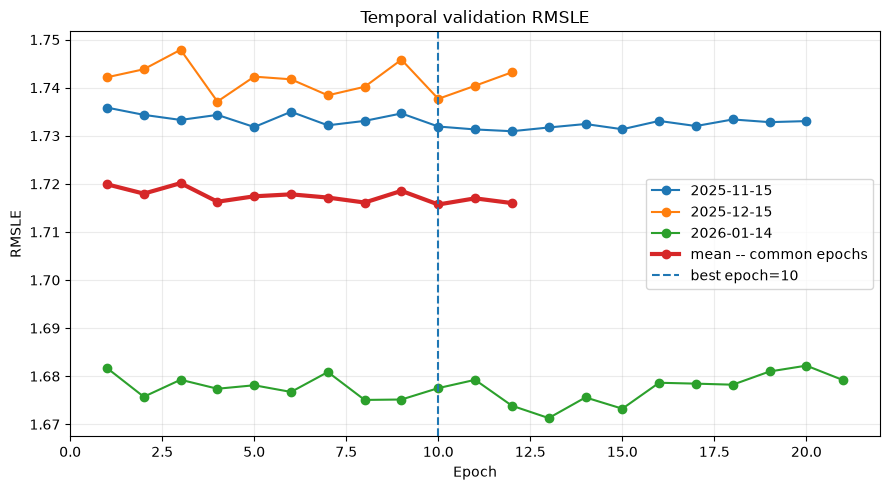

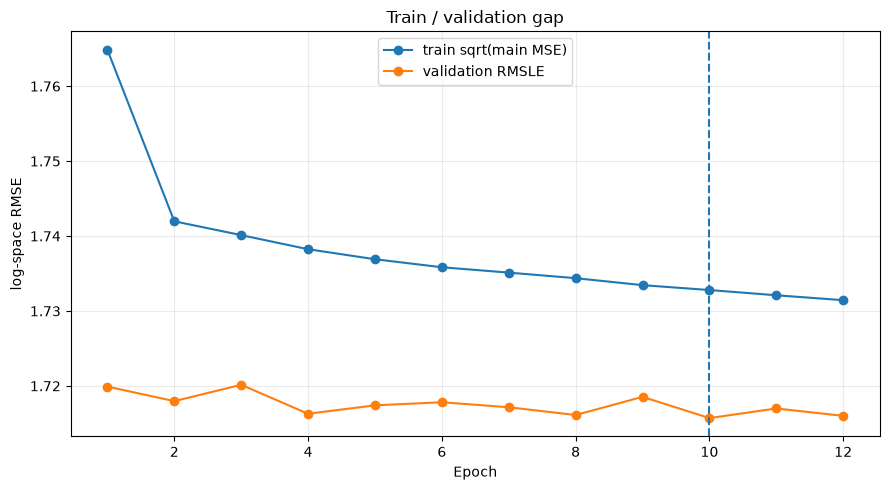

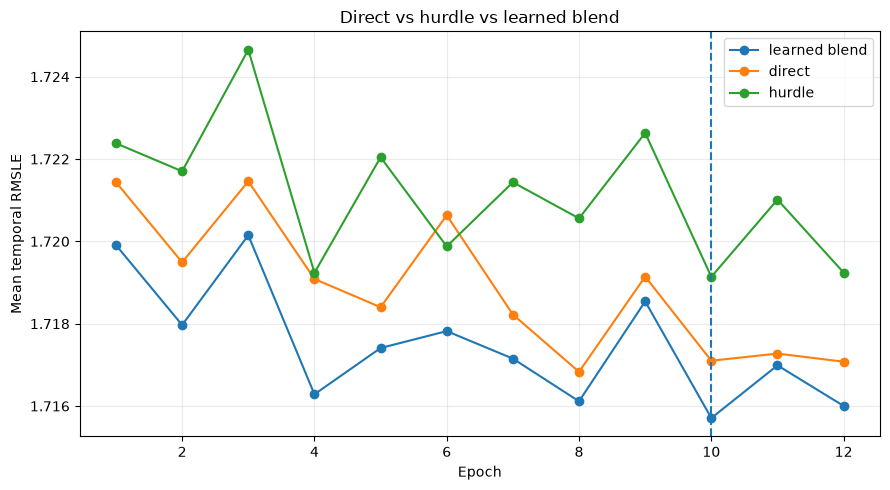

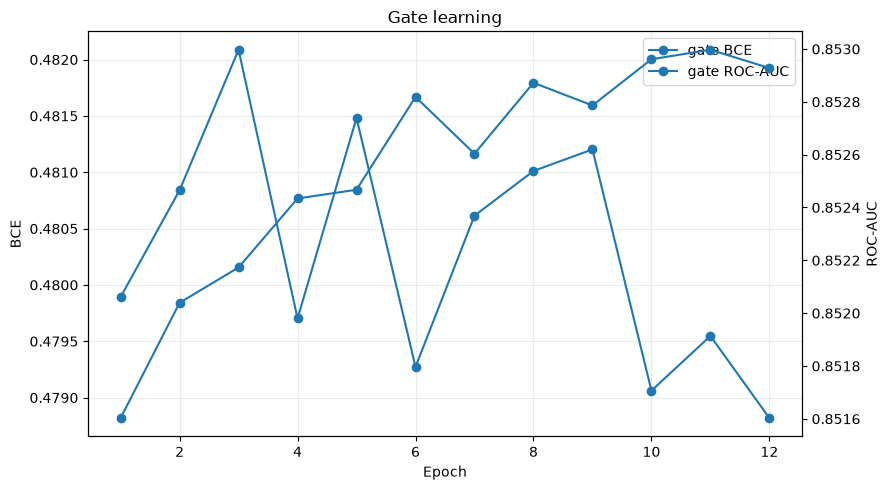

In [8]:
common_epochs = sorted(
    cv_summary["epoch"].unique()
)

common_df = cv_df[
    cv_df["epoch"].isin(common_epochs)
].copy()


# RMSLE по temporal fold.
fig, ax = plt.subplots(figsize=(9, 5))

for cutoff, part in cv_df.groupby("valid_cutoff"):
    part = part.sort_values("epoch")

    ax.plot(
        part["epoch"],
        part["rmsle"],
        marker="o",
        label=cutoff,
    )

mean_curve = (
    common_df.groupby("epoch")["rmsle"]
    .mean()
    .sort_index()
)

ax.plot(
    mean_curve.index,
    mean_curve.values,
    marker="o",
    linewidth=3,
    label="mean -- common epochs",
)

ax.axvline(
    BEST_EPOCH,
    linestyle="--",
    label=f"best epoch={BEST_EPOCH}",
)

ax.set_xlabel("Epoch")
ax.set_ylabel("RMSLE")
ax.set_title("Temporal validation RMSLE")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()

fig.savefig(
    MODEL_DIR / "cv_rmsle_curve.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()


# Train vs validation.
fig, ax = plt.subplots(figsize=(9, 5))

train_mean = (
    common_df.groupby("epoch")["train_rmsle_proxy"]
    .mean()
    .sort_index()
)

valid_mean = (
    common_df.groupby("epoch")["rmsle"]
    .mean()
    .sort_index()
)

ax.plot(
    train_mean.index,
    train_mean.values,
    marker="o",
    label="train sqrt(main MSE)",
)

ax.plot(
    valid_mean.index,
    valid_mean.values,
    marker="o",
    label="validation RMSLE",
)

ax.axvline(
    BEST_EPOCH,
    linestyle="--",
)

ax.set_xlabel("Epoch")
ax.set_ylabel("log-space RMSE")
ax.set_title("Train / validation gap")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()

fig.savefig(
    MODEL_DIR / "train_validation_gap.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()


# Direct vs hurdle vs blend.
fig, ax = plt.subplots(figsize=(9, 5))

curve = (
    common_df.groupby("epoch")[
        ["rmsle", "direct_rmsle", "hurdle_rmsle"]
    ]
    .mean()
    .sort_index()
)

ax.plot(
    curve.index,
    curve["rmsle"],
    marker="o",
    label="learned blend",
)

ax.plot(
    curve.index,
    curve["direct_rmsle"],
    marker="o",
    label="direct",
)

ax.plot(
    curve.index,
    curve["hurdle_rmsle"],
    marker="o",
    label="hurdle",
)

ax.axvline(
    BEST_EPOCH,
    linestyle="--",
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Mean temporal RMSLE")
ax.set_title("Direct vs hurdle vs learned blend")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()

fig.savefig(
    MODEL_DIR / "direct_hurdle_blend_curve.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()


# Gate BCE/AUC.
fig, ax = plt.subplots(figsize=(9, 5))

gate_curve = (
    common_df.groupby("epoch")[
        ["gate_bce", "gate_auc"]
    ]
    .mean()
    .sort_index()
)

line1 = ax.plot(
    gate_curve.index,
    gate_curve["gate_bce"],
    marker="o",
    label="gate BCE",
)

ax.set_xlabel("Epoch")
ax.set_ylabel("BCE")

ax2 = ax.twinx()

line2 = ax2.plot(
    gate_curve.index,
    gate_curve["gate_auc"],
    marker="o",
    label="gate ROC-AUC",
)

ax2.set_ylabel("ROC-AUC")
ax.set_title("Gate learning")
ax.grid(alpha=0.25)

lines = line1 + line2

ax.legend(
    lines,
    [line.get_label() for line in lines],
    loc="best",
)

plt.tight_layout()

fig.savefig(
    MODEL_DIR / "gate_learning_curve.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

## 8. Error analysis -- January fold

January -- самый свежий out-of-time fold, поэтому на нем дополнительно разбираю ошибки выбранной **глобальной** epoch 10.

Важно: это не local January optimum. Local January best был epoch 13 с RMSLE `1.671289`, но final epoch выбирается по трем месяцам, поэтому diagnostics здесь относятся к epoch 10:

```text
January RMSLE at BEST_EPOCH = 1.677522
```

### Что видно по сегментам

```text
zero users RMSLE       = 1.707365
positive Q1 RMSLE      = 1.207919
positive Q5 RMSLE      = 2.124776
```

Самая тяжелая проблема -- верхний positive tail.

Для top positive quintile:

```text
mean true log = 6.046
mean pred log = 4.482
```

То есть крупный будущий GMV систематически недооценивается.

Есть и противоположная ошибка -- несколько пользователей с настоящим `y=0` получают очень большой прогноз.

### Gate

ROC-AUC около `0.856`, а calibration в целом разумная, но predicted probability часто немного выше actual non-zero rate.

Значит bottleneck уже не сводится к простому "classifier плохо понимает zero/non-zero". Значительная часть RMSLE приходит из magnitude/tail ошибок.

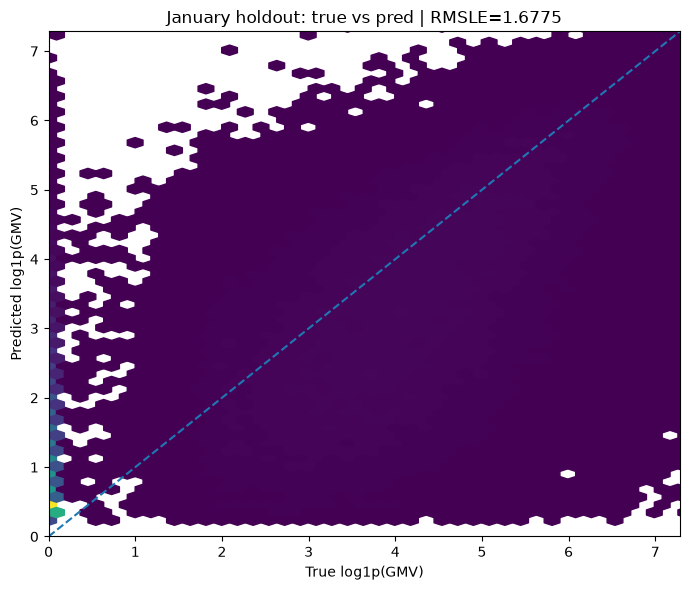

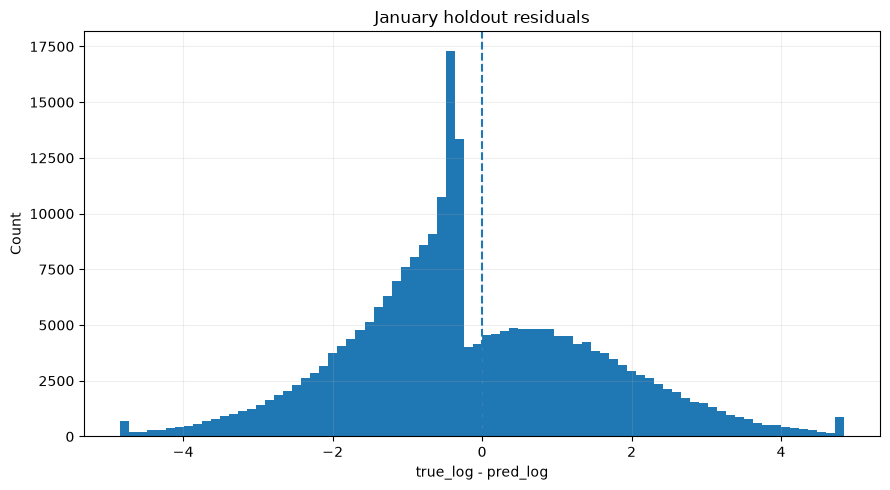

,segment,n,share,rmsle,mean_true_log,mean_pred_log,mean_residual
0,zero,114835,0.459340,1.707365,0.000000,1.386446,-1.386446
1,positive_Q1,27033,0.108132,1.207919,2.297012,2.351517,-0.054505
2,positive_Q2,27033,0.108132,1.380264,3.374946,2.725691,0.649255
3,positive_Q3,27033,0.108132,1.604077,4.134425,3.150190,0.984235
4,positive_Q4,27033,0.108132,1.785877,4.881981,3.674347,1.207634
5,positive_Q5,27033,0.108132,2.124776,6.046467,4.482283,1.564184


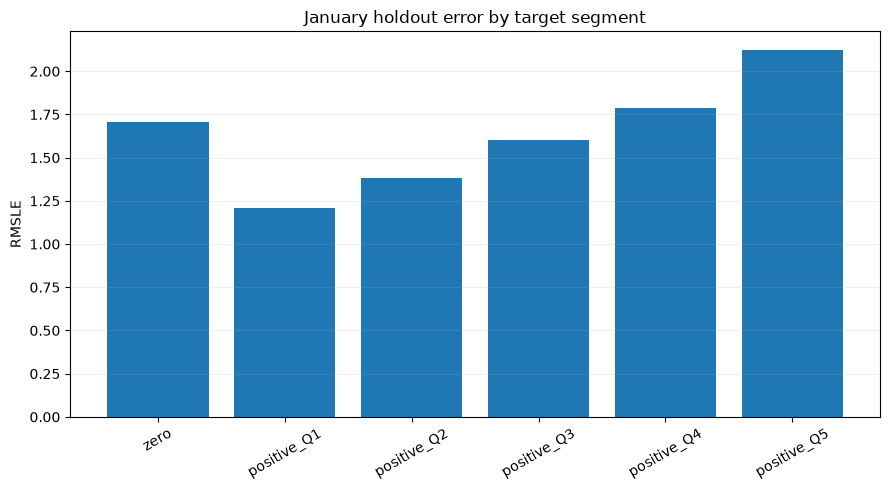

,bin,mean_pred,actual_rate,n
0,"(-0.001, 0.1]",0.097154,0.023729,590
1,"(0.1, 0.2]",0.146507,0.094691,37860
2,"(0.2, 0.3]",0.249857,0.219615,28814
3,"(0.3, 0.4]",0.348805,0.336230,24855
4,"(0.4, 0.5]",0.449695,0.444323,21966
5,"(0.5, 0.6]",0.549299,0.543359,20780
6,"(0.6, 0.7]",0.649791,0.644783,19954
7,"(0.7, 0.8]",0.750181,0.731646,19165
8,"(0.8, 0.9]",0.851321,0.817584,20996
9,"(0.9, 1.0]",0.972366,0.941040,55020


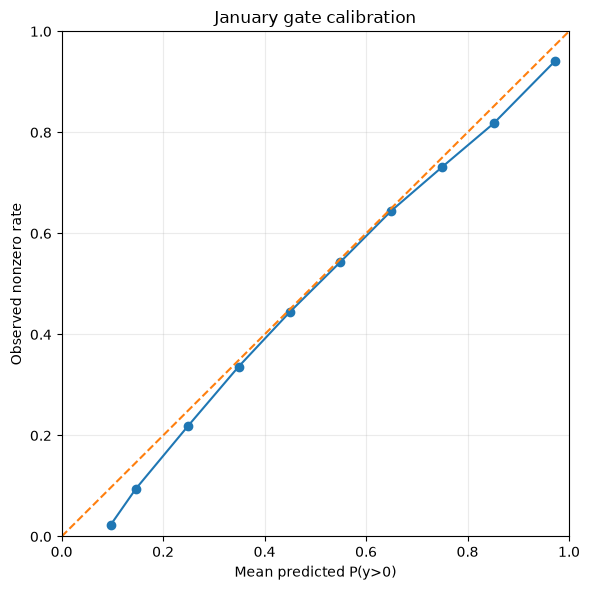

,user_id,y_true,y_pred,target_log,pred_log,residual_log,gate_prob,positive_log,direct_log,hurdle_log
97486,355760,5408.919922,0.597302,8.595989,0.468316,8.127673,0.154693,3.336470,0.415399,0.516129
134849,493918,3135.526123,0.513777,8.050871,0.414608,7.636263,0.135516,3.450102,0.356022,0.467542
74316,270681,9160.305664,4.602639,9.122744,1.723238,7.399506,0.368246,4.212221,1.913715,1.551134
144510,529470,2500.391846,0.550142,7.824603,0.438347,7.386256,0.143354,3.409388,0.382564,0.488748
2476,9355,0.000000,1361.052734,0.000000,7.216748,-7.216748,0.999886,7.210754,7.224292,7.209932
104772,382829,3390.785645,1.573874,8.129112,0.945412,7.183700,0.263222,3.441505,0.989164,0.905881
84543,307751,1799.476929,0.431536,7.495807,0.358748,7.137059,0.123441,3.417830,0.288854,0.421899
182459,669690,1844.452148,0.469485,7.520480,0.384912,7.135568,0.137085,3.216145,0.322962,0.440885
146145,535525,3265.386475,1.646486,8.091439,0.973233,7.118207,0.263407,3.515894,1.025385,0.926111
83959,305585,1536.642944,0.428339,7.338006,0.356512,6.981494,0.123542,3.396513,0.286676,0.419612


In [9]:
best_pred = last_fold_prediction_store[BEST_EPOCH]

target_log = np.log1p(last_fold_y)
pred_log = np.clip(best_pred["pred_log"], 0, None)
pred_value = np.expm1(pred_log)

diag = pd.DataFrame({
    "user_id": last_fold_users,
    "y_true": last_fold_y,
    "y_pred": pred_value,
    "target_log": target_log,
    "pred_log": pred_log,
    "residual_log": target_log - pred_log,
    "sq_error_log": (target_log - pred_log) ** 2,
    "gate_prob": best_pred["gate_prob"],
    "positive_log": best_pred["positive_log"],
    "direct_log": best_pred["direct_log"],
    "hurdle_log": best_pred["hurdle_log"],
})
diag.to_csv(MODEL_DIR / "jan_holdout_diagnostics.csv", index=False)

# True vs pred в log1p.
fig, ax = plt.subplots(figsize=(7, 6))
ax.hexbin(diag["target_log"], diag["pred_log"], gridsize=60, mincnt=1)
limit = float(max(
    diag["target_log"].quantile(0.995),
    diag["pred_log"].quantile(0.995),
))
ax.plot([0, limit], [0, limit], linestyle="--")
ax.set_xlim(0, limit)
ax.set_ylim(0, limit)
ax.set_xlabel("True log1p(GMV)")
ax.set_ylabel("Predicted log1p(GMV)")
ax.set_title(f"January holdout: true vs pred | RMSLE={JAN_RMSLE:.4f}")
plt.tight_layout()
fig.savefig(MODEL_DIR / "jan_true_vs_pred.png", dpi=160, bbox_inches="tight")
plt.show()

# Распределение residual.
fig, ax = plt.subplots(figsize=(9, 5))
clip = float(np.quantile(np.abs(diag["residual_log"]), 0.995))
ax.hist(diag["residual_log"].clip(-clip, clip), bins=80)
ax.axvline(0.0, linestyle="--")
ax.set_xlabel("true_log - pred_log")
ax.set_ylabel("Count")
ax.set_title("January holdout residuals")
ax.grid(alpha=0.20)
plt.tight_layout()
fig.savefig(MODEL_DIR / "jan_residual_hist.png", dpi=160, bbox_inches="tight")
plt.show()

# Нули + positive-квинтили.
diag["segment"] = "zero"
positive_idx = diag["y_true"] > 0
positive_rank = diag.loc[positive_idx, "target_log"].rank(method="first")
diag.loc[positive_idx, "segment"] = pd.qcut(
    positive_rank,
    q=5,
    labels=["positive_Q1", "positive_Q2", "positive_Q3", "positive_Q4", "positive_Q5"],
).astype(str)

segment_order = [
    "zero",
    "positive_Q1",
    "positive_Q2",
    "positive_Q3",
    "positive_Q4",
    "positive_Q5",
]

segment_rows = []
for segment in segment_order:
    part = diag[diag["segment"] == segment]
    if len(part) == 0:
        continue
    segment_rows.append({
        "segment": segment,
        "n": len(part),
        "share": len(part) / len(diag),
        "rmsle": float(np.sqrt(part["sq_error_log"].mean())),
        "mean_true_log": float(part["target_log"].mean()),
        "mean_pred_log": float(part["pred_log"].mean()),
        "mean_residual": float(part["residual_log"].mean()),
    })

segment_df = pd.DataFrame(segment_rows)
display(segment_df)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(segment_df["segment"], segment_df["rmsle"])
ax.set_ylabel("RMSLE")
ax.set_title("January holdout error by target segment")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.20)
plt.tight_layout()
fig.savefig(MODEL_DIR / "jan_segment_rmsle.png", dpi=160, bbox_inches="tight")
plt.show()

# Calibration gate.
calibration = pd.DataFrame({
    "p": diag["gate_prob"],
    "nonzero": (diag["y_true"] > 0).astype(float),
})
calibration["bin"] = pd.cut(
    calibration["p"],
    bins=np.linspace(0, 1, 11),
    include_lowest=True,
)
calibration_df = (
    calibration.groupby("bin", observed=True)
    .agg(
        mean_pred=("p", "mean"),
        actual_rate=("nonzero", "mean"),
        n=("nonzero", "size"),
    )
    .reset_index()
)
display(calibration_df)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(calibration_df["mean_pred"], calibration_df["actual_rate"], marker="o")
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Mean predicted P(y>0)")
ax.set_ylabel("Observed nonzero rate")
ax.set_title("January gate calibration")
ax.grid(alpha=0.25)
plt.tight_layout()
fig.savefig(MODEL_DIR / "jan_gate_calibration.png", dpi=160, bbox_inches="tight")
plt.show()

worst_errors = (
    diag.assign(abs_error=lambda x: np.abs(x["residual_log"]))
    .sort_values("abs_error", ascending=False)
    .head(30)
    [[
        "user_id",
        "y_true",
        "y_pred",
        "target_log",
        "pred_log",
        "residual_log",
        "gate_prob",
        "positive_log",
        "direct_log",
        "hurdle_log",
    ]]
)
display(worst_errors)

## 9. Optional January LightGBM gate oracle -- в этом run выключен

```python
RUN_JAN_GATE_ORACLE = False
```

Эти клетки оставлены как отдельный exploratory experiment тиммейта.

В фактическом run они только напечатали `SKIPPED`:

- LightGBM не импортировался;
- новые модели не обучались;
- никакие oracle predictions не участвовали в CV;
- никакие oracle predictions не участвовали в final submission.

Поэтому public `1.6506631932` -- чистый результат Joint Hurdle BiLSTM + three-seed ensemble.

In [10]:
RUN_JAN_GATE_ORACLE = False

if not RUN_JAN_GATE_ORACLE:
    print("January gate oracle: SKIPPED")
else:
    import gc
    import importlib.util
    import time

    import numpy as np
    import pandas as pd

    if importlib.util.find_spec("lightgbm") is None:
        raise ImportError(
            "Установите зависимости:\n"
            "pip install -r notebooks/modeling/two_stage_v2/requirements-v2.txt"
        )

    import lightgbm as lgb
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
    from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit


    ORACLE_SEED = 2026
    ORACLE_OUTER_FOLDS = 5

    # Насколько сильно разрешаем LightGBM менять вероятность LSTM.
    ORACLE_LAMBDA_GRID = np.linspace(0.0, 1.0, 11)

    # Компактная модель: это тест гипотезы, не финальный тюнинг.
    ORACLE_MAX_TREES = 1500
    ORACLE_EARLY_STOPPING_ROUNDS = 100
    ORACLE_N_JOBS = -1

    PROB_EPS = 1e-6


    def clip_probability(probability):
        return np.clip(
            np.asarray(probability, dtype=np.float64),
            PROB_EPS,
            1.0 - PROB_EPS,
        )


    def probability_logit(probability):
        probability = clip_probability(probability)
        return np.log(probability) - np.log1p(-probability)


    def probability_sigmoid(logit):
        logit = np.clip(np.asarray(logit, dtype=np.float64), -40.0, 40.0)
        return 1.0 / (1.0 + np.exp(-logit))


    def fit_platt(probability, target, seed):
        """
        Обычная Platt-калибровка:
        sigmoid(a * logit(p) + b).
        """
        target = np.asarray(target, dtype=np.int8)

        if np.unique(target).size != 2:
            raise ValueError("Platt calibration needs both target classes")

        calibrator = LogisticRegression(
            C=10.0,
            solver="lbfgs",
            max_iter=1000,
            random_state=seed,
        )
        calibrator.fit(
            probability_logit(probability).reshape(-1, 1),
            target,
        )
        return calibrator


    def apply_platt(calibrator, probability):
        return calibrator.predict_proba(
            probability_logit(probability).reshape(-1, 1)
        )[:, 1]


    def blend_probabilities_logit(
        lstm_probability,
        oracle_probability,
        weight,
    ):
        """
        weight=0 -> только LSTM.
        weight=1 -> только LightGBM.
    
        Смешиваем logits, а не сами вероятности:
        это устойчивее около 0 и 1.
        """
        if not 0.0 <= weight <= 1.0:
            raise ValueError("weight must be in [0, 1]")

        blended_logit = (
            (1.0 - weight) * probability_logit(lstm_probability)
            + weight * probability_logit(oracle_probability)
        )
        return probability_sigmoid(blended_logit)


    def optimal_alpha(target_log, hurdle_log, direct_log):
        """
        Аналитически находит лучший вес:

            prediction =
                alpha * hurdle_log
                + (1 - alpha) * direct_log

        Так как RMSLE — это RMSE в log1p-space,
        alpha можно найти как решение одномерной least-squares задачи.
        """
        target_log = np.asarray(target_log, dtype=np.float64)
        hurdle_log = np.asarray(hurdle_log, dtype=np.float64)
        direct_log = np.asarray(direct_log, dtype=np.float64)

        direction = hurdle_log - direct_log
        denominator = float(direction @ direction)

        if denominator <= 1e-12:
            return 0.0

        alpha = float(
            direction @ (target_log - direct_log)
            / denominator
        )
        return float(np.clip(alpha, 0.0, 1.0))


    def compose_log_prediction(
        gate_probability,
        positive_log,
        direct_log,
        alpha,
    ):
        """
        1. gate_probability определяет вероятность ненулевого месяца.
        2. positive_log оценивает GMV при условии активности.
        3. direct_log — независимый regression head.
        4. alpha смешивает hurdle и direct predictions.
        """
        if not 0.0 <= alpha <= 1.0:
            raise ValueError("alpha must be in [0, 1]")

        gate_probability = np.asarray(
            gate_probability, dtype=np.float64
        )
        positive_log = np.asarray(positive_log, dtype=np.float64)
        direct_log = np.asarray(direct_log, dtype=np.float64)

        if not (
            gate_probability.shape
            == positive_log.shape
            == direct_log.shape
        ):
            raise ValueError("gate/head arrays must have equal shapes")

        values = np.column_stack([
            gate_probability,
            positive_log,
            direct_log,
        ])
        if not np.isfinite(values).all():
            raise ValueError("gate/head arrays must be finite")

        if np.any(
            (gate_probability < 0.0)
            | (gate_probability > 1.0)
        ):
            raise ValueError("gate_probability must be in [0, 1]")

        hurdle_log = gate_probability * positive_log

        prediction = (
            alpha * hurdle_log
            + (1.0 - alpha) * direct_log
        )
        return np.clip(prediction, 0.0, None)


    def rmsle_from_logs(target_log, prediction_log):
        error = (
            np.asarray(target_log)
            - np.asarray(prediction_log)
        )
        return float(np.sqrt(np.mean(error * error)))


    def select_lambda_and_alpha(
        lstm_probability,
        oracle_probability,
        positive_log,
        direct_log,
        target_log,
        lambda_grid,
    ):
        """
        На отдельной tuning-выборке совместно выбирает:
        - lambda: насколько доверять LightGBM;
        - alpha: насколько доверять hurdle-head.
        """
        candidates = []

        for weight in lambda_grid:
            blended_probability = blend_probabilities_logit(
                lstm_probability,
                oracle_probability,
                float(weight),
            )

            hurdle_log = blended_probability * positive_log
            alpha = optimal_alpha(
                target_log,
                hurdle_log,
                direct_log,
            )

            prediction_log = compose_log_prediction(
                blended_probability,
                positive_log,
                direct_log,
                alpha,
            )

            candidates.append({
                "lambda": float(weight),
                "alpha": alpha,
                "rmsle": rmsle_from_logs(
                    target_log,
                    prediction_log,
                ),
            })

        # При равном качестве предпочитаем меньше вмешиваться в LSTM.
        return min(
            candidates,
            key=lambda row: (row["rmsle"], row["lambda"]),
        )


    def stratified_split(
        indices,
        target,
        test_size,
        seed,
    ):
        indices = np.asarray(indices)

        splitter = StratifiedShuffleSplit(
            n_splits=1,
            test_size=test_size,
            random_state=seed,
        )

        train_local, test_local = next(
            splitter.split(
                np.zeros(len(indices), dtype=np.int8),
                target[indices],
            )
        )

        return indices[train_local], indices[test_local]


    def make_oracle_model(seed, n_estimators):
        return lgb.LGBMClassifier(
            objective="binary",
            n_estimators=n_estimators,
            learning_rate=0.03,

            # Небольшие деревья снижают риск запоминания января.
            num_leaves=15,
            max_depth=4,
            min_child_samples=1000,

            subsample=0.80,
            subsample_freq=1,
            colsample_bytree=0.75,

            reg_alpha=0.5,
            reg_lambda=2.0,
            max_bin=127,

            random_state=seed,
            n_jobs=ORACLE_N_JOBS,
            verbosity=-1,

            deterministic=True,
            force_col_wise=True,
        )


    # Мини-тесты самых опасных формул.
    _test_lstm = np.array([0.2, 0.8])
    _test_oracle = np.array([0.7, 0.3])

    np.testing.assert_allclose(
        blend_probabilities_logit(
            _test_lstm, _test_oracle, 0.0
        ),
        _test_lstm,
    )
    np.testing.assert_allclose(
        blend_probabilities_logit(
            _test_lstm, _test_oracle, 1.0
        ),
        _test_oracle,
    )

    _test_hurdle = np.array([0.0, 2.0, 4.0, 6.0])
    _test_direct = np.ones(4)
    _test_target = (
        0.75 * _test_hurdle
        + 0.25 * _test_direct
    )

    assert abs(
        optimal_alpha(
            _test_target,
            _test_hurdle,
            _test_direct,
        )
        - 0.75
    ) < 1e-12

    print("Oracle helper checks: OK")

    # Standalone bootstrap: this oracle cell can run in a clean kernel.
    from pathlib import Path
    import json


    def find_oracle_project_root(start=None):
        start = Path.cwd() if start is None else Path(start).resolve()
        for candidate in [start, *start.parents]:
            if (
                (candidate / "data" / "lstm" / "meta.json").exists()
                and (
                    candidate
                    / "models"
                    / "lstm_hurdle_v4_robust"
                    / "jan_holdout_diagnostics.csv"
                ).exists()
            ):
                return candidate
        raise FileNotFoundError(
            "Не найден корень проекта с data/lstm/meta.json и January diagnostics"
        )


    PROJECT_ROOT = find_oracle_project_root()
    DATA_DIR = PROJECT_ROOT / "data" / "lstm"
    MODEL_DIR = PROJECT_ROOT / "models" / "lstm_hurdle_v4_robust"

    with open(DATA_DIR / "meta.json", encoding="utf-8") as file:
        META = json.load(file)

    if META.get("format_version") != 2:
        raise RuntimeError("Oracle expects data/lstm format_version=2")

    SEQ_LEN = int(META["seq_len"])
    diag_path = MODEL_DIR / "jan_holdout_diagnostics.csv"

    if "diag" not in globals():
        diag = pd.read_csv(diag_path)
    else:
        diag = diag.copy()

    diag = diag.reset_index(drop=True)


    required_diagnostic_columns = {
        "user_id",
        "y_true",
        "target_log",
        "pred_log",
        "gate_prob",
        "positive_log",
        "direct_log",
        "hurdle_log",
    }

    missing_columns = (
        required_diagnostic_columns
        - set(diag.columns)
    )

    if missing_columns:
        raise KeyError(
            f"Missing diagnostic columns: {sorted(missing_columns)}"
        )


    # Проверяем, что diagnostic и static.npy относятся
    # к одним пользователям и стоят в одном порядке.
    jan_cutoff = META["labeled_cutoffs"][-1]
    jan_dir = DATA_DIR / jan_cutoff

    jan_users = np.load(jan_dir / "user_id.npy")
    diag_users = diag["user_id"].to_numpy(
        dtype=jan_users.dtype,
        copy=False,
    )

    assert not diag["user_id"].isna().any()
    assert diag["user_id"].is_unique
    assert len(diag) == len(jan_users)
    assert np.array_equal(diag_users, jan_users)


    user_index_path = jan_dir / "user_index.npy"
    all_users_path = DATA_DIR / "all_user_ids.npy"

    if user_index_path.exists() and all_users_path.exists():
        user_index = np.load(user_index_path)
        all_users = np.load(all_users_path)

        assert np.array_equal(
            all_users[user_index],
            jan_users,
        )


    raw_static = np.load(
        jan_dir / "static.npy",
        mmap_mode="r",
    )
    history_length = np.load(
        jan_dir / "history_length.npy"
    )

    raw_static_names = list(META["static_features"])

    assert raw_static.shape[0] == len(diag)
    assert raw_static.shape[1] == len(raw_static_names)
    assert len(raw_static_names) == len(set(raw_static_names))
    assert len(history_length) == len(diag)
    assert np.all(
        (history_length >= 1)
        & (history_length <= SEQ_LEN)
    )


    # Компактный набор, чтобы первый эксперимент был быстрым.
    # Он покрывает recency, frequency, monetary value,
    # engagement, тренды и признаки необычных клиентов.
    oracle_static_names = [
        "customer_age_days",
        "never_purchased",
        "days_since_last_purchase",
        "days_since_last_activity",
        "days_since_last_search",
        "days_since_last_cart",

        "gmv_7d",
        "gmv_30d",
        "gmv_90d",

        "purchased_items_7d",
        "purchased_items_30d",
        "purchased_items_90d",

        "searches_7d",
        "searches_30d",
        "searches_90d",

        "active_days_30d",
        "active_days_90d",

        "gmv_trend_log",
        "intent_trend_log",
        "whale_score",

        "purchase_frequency",
        "recency_ratio",
        "active_day_rate_lifetime",
        "no_recent_engagement",

        "gmv_per_item",
        "gmv_daily_mean",
        "search_to_purchase_freq",

        "searches_trend_log",
        "purchased_items_trend_log",
        "active_days_trend_log",
    ]

    missing_static = sorted(
        set(oracle_static_names)
        - set(raw_static_names)
    )

    if missing_static:
        raise KeyError(
            f"Static features missing from metadata: {missing_static}"
        )


    # Frozen LSTM outputs.
    lstm_gate = clip_probability(
        diag["gate_prob"].to_numpy()
    )
    positive_log = diag[
        "positive_log"
    ].to_numpy(dtype=np.float64)
    direct_log = diag[
        "direct_log"
    ].to_numpy(dtype=np.float64)
    hurdle_log = diag[
        "hurdle_log"
    ].to_numpy(dtype=np.float64)
    original_pred_log = diag[
        "pred_log"
    ].to_numpy(dtype=np.float64)

    # Эти два массива используются только как labels/evaluation,
    # они не попадут в X_oracle.
    target_log = diag[
        "target_log"
    ].to_numpy(dtype=np.float64)
    target_active = (
        diag["y_true"].to_numpy() > 0
    ).astype(np.int8)


    assert np.unique(target_active).size == 2
    assert np.isfinite(
        np.column_stack([
            lstm_gate,
            positive_log,
            direct_log,
            hurdle_log,
            original_pred_log,
            target_log,
        ])
    ).all()

    assert (positive_log >= 0).all()
    assert (direct_log >= 0).all()


    # Признаки, описывающие мнение самой LSTM
    # и внутренние противоречия между её heads.
    meta_columns = {
        "lstm_gate_prob":
            lstm_gate.astype(np.float32),

        "lstm_gate_logit":
            probability_logit(lstm_gate).astype(np.float32),

        # Максимум при p=0.5 — зона неуверенности.
        "lstm_gate_uncertainty":
            (lstm_gate * (1.0 - lstm_gate)).astype(np.float32),

        "lstm_gate_entropy": (
            -lstm_gate * np.log(lstm_gate)
            - (1.0 - lstm_gate) * np.log1p(-lstm_gate)
        ).astype(np.float32),

        "lstm_pred_log":
            original_pred_log.astype(np.float32),

        "lstm_positive_log":
            positive_log.astype(np.float32),

        "lstm_direct_log":
            direct_log.astype(np.float32),

        "lstm_hurdle_log":
            hurdle_log.astype(np.float32),

        "positive_minus_direct":
            (positive_log - direct_log).astype(np.float32),

        "hurdle_minus_direct":
            (hurdle_log - direct_log).astype(np.float32),

        "pred_minus_direct":
            (original_pred_log - direct_log).astype(np.float32),

        "pred_minus_hurdle":
            (original_pred_log - hurdle_log).astype(np.float32),

        "history_length":
            history_length.astype(np.float32),
    }


    # Важно: извлекаем static по именам, а не по предполагаемым позициям.
    for feature_name in oracle_static_names:
        column_index = raw_static_names.index(feature_name)

        meta_columns[feature_name] = np.asarray(
            raw_static[:, column_index],
            dtype=np.float32,
        )


    X_oracle = (
        pd.DataFrame(meta_columns)
        .replace([np.inf, -np.inf], np.nan)
    )


    # Защита от случайного попадания target/identity.
    forbidden_tokens = (
        "target",
        "residual",
        "sq_error",
        "y_true",
        "user_id",
    )

    assert not any(
        token in column.lower()
        for column in X_oracle.columns
        for token in forbidden_tokens
    )

    model_output_columns = [
        column
        for column in X_oracle.columns
        if column.startswith("lstm_")
    ]

    assert np.isfinite(
        X_oracle[model_output_columns].to_numpy()
    ).all()


    print("January rows:", len(X_oracle))
    print("Oracle features:", X_oracle.shape[1])
    print(
        "Positive class share:",
        f"{target_active.mean():.3%}",
    )
    print(
        "Meta-table memory:",
        f"{X_oracle.memory_usage(deep=True).sum() / 2**20:.1f} MiB",
    )

January gate oracle: SKIPPED


lambda отвечает за силу вмешательства LightGBM, alpha -- за новый баланс между hurdle и direct heads. Их нельзя подбирать на той же выборке, на которой мы измеряем итоговый RMSLE иначе будет утечка данных

# Построение meta-таблицы

В X_oracle принципиально нет:
- user_id;
- y_true;
- target_log;
- residual_log;
- sq_error_log.
LightGBM видит только информацию, доступную на момент прогноза.

# Nested cross-fitting оракула

In [11]:
if not RUN_JAN_GATE_ORACLE:
    print("January gate oracle block: SKIPPED")
else:
    n_rows = len(X_oracle)

    oof_platt_gate = np.full(
        n_rows, np.nan, dtype=np.float64
    )
    oof_meta_gate = np.full(
        n_rows, np.nan, dtype=np.float64
    )
    oof_oracle_gate = np.full(
        n_rows, np.nan, dtype=np.float64
    )

    oof_platt_pred_log = np.full(
        n_rows, np.nan, dtype=np.float64
    )
    oof_oracle_pred_log = np.full(
        n_rows, np.nan, dtype=np.float64
    )

    fold_rows = []
    feature_gain = np.zeros(
        X_oracle.shape[1],
        dtype=np.float64,
    )


    outer_cv = StratifiedKFold(
        n_splits=ORACLE_OUTER_FOLDS,
        shuffle=True,
        random_state=ORACLE_SEED,
    )


    for fold, (outer_train, outer_test) in enumerate(
        outer_cv.split(X_oracle, target_active),
        start=1,
    ):
        started = time.time()
        seed = ORACLE_SEED + fold

        # 1. tuning: только lambda и alpha.
        development, tuning = stratified_split(
            outer_train,
            target_active,
            test_size=0.20,
            seed=seed,
        )

        # 2. calibration: только Platt.
        core, calibration = stratified_split(
            development,
            target_active,
            test_size=0.20,
            seed=seed + 100,
        )

        # 3. early_stop: только выбор числа деревьев.
        fit_rows, early_stop = stratified_split(
            core,
            target_active,
            test_size=0.20,
            seed=seed + 200,
        )

        # 4. outer_test не участвует ни в одном выборе.
        split_arrays = [
            fit_rows,
            early_stop,
            calibration,
            tuning,
            outer_test,
        ]

        combined_rows = np.concatenate(split_arrays)

        assert len(combined_rows) == n_rows
        assert np.unique(combined_rows).size == n_rows
        assert all(
            np.unique(target_active[rows]).size == 2
            for rows in split_arrays
        )

        # Сначала маленький probe-run для выбора числа деревьев.
        probe = make_oracle_model(
            seed,
            ORACLE_MAX_TREES,
        )

        probe.fit(
            X_oracle.iloc[fit_rows],
            target_active[fit_rows],

            eval_set=[(
                X_oracle.iloc[early_stop],
                target_active[early_stop],
            )],
            eval_metric="binary_logloss",

            callbacks=[
                lgb.early_stopping(
                    ORACLE_EARLY_STOPPING_ROUNDS,
                    verbose=False,
                ),
                lgb.log_evaluation(0),
            ],
        )

        best_iteration = int(
            probe.best_iteration_
            or ORACLE_MAX_TREES
        )

        # После выбора количества деревьев переобучаем
        # только LightGBM на fit + early_stop.
        oracle = make_oracle_model(
            seed,
            best_iteration,
        )
        oracle.fit(
            X_oracle.iloc[core],
            target_active[core],
        )

        # LightGBM probability до калибровки.
        meta_calibration_raw = oracle.predict_proba(
            X_oracle.iloc[calibration]
        )[:, 1]

        meta_tuning_raw = oracle.predict_proba(
            X_oracle.iloc[tuning]
        )[:, 1]

        meta_test_raw = oracle.predict_proba(
            X_oracle.iloc[outer_test]
        )[:, 1]

        # Platt поверх LightGBM.
        meta_platt = fit_platt(
            meta_calibration_raw,
            target_active[calibration],
            seed,
        )

        meta_tuning = apply_platt(
            meta_platt,
            meta_tuning_raw,
        )
        meta_test = apply_platt(
            meta_platt,
            meta_test_raw,
        )

        # Отдельный дешёвый baseline:
        # что даст одна калибровка LSTM без LightGBM?
        lstm_platt = fit_platt(
            lstm_gate[calibration],
            target_active[calibration],
            seed,
        )

        lstm_platt_tuning = apply_platt(
            lstm_platt,
            lstm_gate[tuning],
        )
        lstm_platt_test = apply_platt(
            lstm_platt,
            lstm_gate[outer_test],
        )

        platt_choice = select_lambda_and_alpha(
            lstm_probability=lstm_gate[tuning],
            oracle_probability=lstm_platt_tuning,
            positive_log=positive_log[tuning],
            direct_log=direct_log[tuning],
            target_log=target_log[tuning],

            # Здесь lambda=1 означает:
            # полностью заменить gate его Platt-версией.
            lambda_grid=np.array([1.0]),
        )

        platt_test_pred = compose_log_prediction(
            gate_probability=lstm_platt_test,
            positive_log=positive_log[outer_test],
            direct_log=direct_log[outer_test],
            alpha=platt_choice["alpha"],
        )

        # Выбираем силу вмешательства LightGBM.
        oracle_choice = select_lambda_and_alpha(
            lstm_probability=lstm_gate[tuning],
            oracle_probability=meta_tuning,
            positive_log=positive_log[tuning],
            direct_log=direct_log[tuning],
            target_log=target_log[tuning],
            lambda_grid=ORACLE_LAMBDA_GRID,
        )

        oracle_test_gate = blend_probabilities_logit(
            lstm_gate[outer_test],
            meta_test,
            oracle_choice["lambda"],
        )

        oracle_test_pred = compose_log_prediction(
            gate_probability=oracle_test_gate,
            positive_log=positive_log[outer_test],
            direct_log=direct_log[outer_test],
            alpha=oracle_choice["alpha"],
        )

        # Каждый пользователь получает предсказание модели,
        # которая не видела его target.
        oof_platt_gate[outer_test] = lstm_platt_test
        oof_meta_gate[outer_test] = meta_test
        oof_oracle_gate[outer_test] = oracle_test_gate

        oof_platt_pred_log[outer_test] = platt_test_pred
        oof_oracle_pred_log[outer_test] = oracle_test_pred

        # Нормализованный gain importance.
        gain = oracle.booster_.feature_importance(
            importance_type="gain"
        )

        if gain.sum() > 0:
            feature_gain += gain / gain.sum()

        original_fold_rmsle = rmsle_from_logs(
            target_log[outer_test],
            original_pred_log[outer_test],
        )
        platt_fold_rmsle = rmsle_from_logs(
            target_log[outer_test],
            platt_test_pred,
        )
        oracle_fold_rmsle = rmsle_from_logs(
            target_log[outer_test],
            oracle_test_pred,
        )

        fold_rows.append({
            "fold": fold,
            "n_test": len(outer_test),
            "n_fit": len(fit_rows),
            "n_early_stop": len(early_stop),
            "n_calibration": len(calibration),
            "n_tuning": len(tuning),

            "best_iteration": best_iteration,
            "lambda": oracle_choice["lambda"],
            "alpha_platt": platt_choice["alpha"],
            "alpha_oracle": oracle_choice["alpha"],

            "rmsle_original": original_fold_rmsle,
            "rmsle_platt": platt_fold_rmsle,
            "rmsle_oracle": oracle_fold_rmsle,

            "delta_oracle": (
                oracle_fold_rmsle
                - original_fold_rmsle
            ),
            "seconds": time.time() - started,
        })

        print(
            f"fold={fold} "
            f"trees={best_iteration} "
            f"lambda={oracle_choice['lambda']:.2f} "
            f"alpha={oracle_choice['alpha']:.3f} | "
            f"RMSLE {original_fold_rmsle:.6f} "
            f"-> {oracle_fold_rmsle:.6f} "
            f"({oracle_fold_rmsle - original_fold_rmsle:+.6f})"
        )

        del probe, oracle, meta_platt, lstm_platt
        gc.collect()


    for output in [
        oof_platt_gate,
        oof_meta_gate,
        oof_oracle_gate,
        oof_platt_pred_log,
        oof_oracle_pred_log,
    ]:
        assert np.isfinite(output).all(), (
            "OOF array contains unfilled rows"
        )


    fold_results = pd.DataFrame(fold_rows)
    display(fold_results)

January gate oracle block: SKIPPED


Внутри каждого outer-fold находятся четыре непересекающиеся роли:

```
outer train
├── fit          → обучение LightGBM
├── early_stop   → количество деревьев
├── calibration  → Platt
└── tuning       → lambda и alpha

outer test       → только итоговая оценка
```

# Проверка гипотезы

In [12]:
if not RUN_JAN_GATE_ORACLE:
    print("January gate oracle block: SKIPPED")
else:
    positive_mask = target_active == 1

    positive_q5_threshold = np.quantile(
        target_log[positive_mask],
        0.80,
    )
    positive_q5_mask = (
        positive_mask
        & (target_log >= positive_q5_threshold)
    )


    def evaluation_row(
        name,
        gate_probability,
        prediction_log,
    ):
        probability = clip_probability(
            gate_probability
        )

        rmsle = rmsle_from_logs(
            target_log,
            prediction_log,
        )
        original_rmsle = rmsle_from_logs(
            target_log,
            original_pred_log,
        )

        return {
            "model": name,
            "RMSLE": rmsle,
            "delta_vs_original": rmsle - original_rmsle,

            "gate_logloss": log_loss(
                target_active,
                probability,
                labels=[0, 1],
            ),
            "gate_AUC": roc_auc_score(
                target_active,
                probability,
            ),
            "gate_Brier": brier_score_loss(
                target_active,
                probability,
            ),

            "RMSLE_zero": rmsle_from_logs(
                target_log[~positive_mask],
                prediction_log[~positive_mask],
            ),
            "RMSLE_positive": rmsle_from_logs(
                target_log[positive_mask],
                prediction_log[positive_mask],
            ),
            "RMSLE_positive_Q5": rmsle_from_logs(
                target_log[positive_q5_mask],
                prediction_log[positive_q5_mask],
            ),
        }


    oracle_report = pd.DataFrame([
        evaluation_row(
            "Original LSTM",
            lstm_gate,
            original_pred_log,
        ),
        evaluation_row(
            "Platt(LSTM gate) + tuned alpha",
            oof_platt_gate,
            oof_platt_pred_log,
        ),
        evaluation_row(
            "LightGBM oracle + logit blend",
            oof_oracle_gate,
            oof_oracle_pred_log,
        ),
    ])

    display(oracle_report)


    # Качество самого LightGBM-классификатора
    # до смешивания с LSTM.
    meta_gate_report = pd.DataFrame([
        {
            "gate": "Original LSTM",
            "logloss": log_loss(
                target_active,
                clip_probability(lstm_gate),
                labels=[0, 1],
            ),
            "AUC": roc_auc_score(
                target_active,
                lstm_gate,
            ),
            "Brier": brier_score_loss(
                target_active,
                lstm_gate,
            ),
        },
        {
            "gate": "LightGBM calibrated before blend",
            "logloss": log_loss(
                target_active,
                clip_probability(oof_meta_gate),
                labels=[0, 1],
            ),
            "AUC": roc_auc_score(
                target_active,
                oof_meta_gate,
            ),
            "Brier": brier_score_loss(
                target_active,
                oof_meta_gate,
            ),
        },
    ])

    display(meta_gate_report)


    feature_importance = (
        pd.DataFrame({
            "feature": X_oracle.columns,
            "mean_gain_share": (
                feature_gain
                / ORACLE_OUTER_FOLDS
            ),
        })
        .sort_values(
            "mean_gain_share",
            ascending=False,
            ignore_index=True,
        )
    )

    display(feature_importance.head(25))


    def paired_bootstrap_rmsle_delta(
        target_log,
        baseline_log,
        candidate_log,
        n_resamples=300,
        seed=ORACLE_SEED,
    ):
        """
        Быстрый paired bootstrap по пользователям.

        Для окончательного отчёта можно поднять
        n_resamples до 2000.
        """
        rng = np.random.default_rng(seed)

        baseline_sq = (
            target_log - baseline_log
        ) ** 2
        candidate_sq = (
            target_log - candidate_log
        ) ** 2

        deltas = np.empty(
            n_resamples,
            dtype=np.float64,
        )
        n = len(target_log)

        for iteration in range(n_resamples):
            sample = rng.integers(
                0,
                n,
                size=n,
            )

            deltas[iteration] = (
                np.sqrt(candidate_sq[sample].mean())
                - np.sqrt(baseline_sq[sample].mean())
            )

        return np.quantile(
            deltas,
            [0.025, 0.50, 0.975],
        )


    bootstrap_ci = paired_bootstrap_rmsle_delta(
        target_log,
        original_pred_log,
        oof_oracle_pred_log,
    )

    overall_delta = (
        rmsle_from_logs(
            target_log,
            oof_oracle_pred_log,
        )
        - rmsle_from_logs(
            target_log,
            original_pred_log,
        )
    )

    better_folds = int(
        (fold_results["delta_oracle"] < 0).sum()
    )


    original_row = (
        oracle_report
        .set_index("model")
        .loc["Original LSTM"]
    )
    oracle_row = (
        oracle_report
        .set_index("model")
        .loc["LightGBM oracle + logit blend"]
    )

    guardrails_pass = bool(
        oracle_row["gate_logloss"]
        <= original_row["gate_logloss"] + 0.01

        and oracle_row["gate_Brier"]
        <= original_row["gate_Brier"] + 0.01

        and oracle_row["RMSLE_zero"]
        <= original_row["RMSLE_zero"] + 0.02

        and oracle_row["RMSLE_positive_Q5"]
        <= original_row["RMSLE_positive_Q5"] + 0.02
    )


    # Диагностическая верхняя граница.
    # Здесь используется настоящий label — это НЕ модель.
    current_direction = hurdle_log - direct_log

    current_alpha = float(np.clip(
        current_direction
        @ (original_pred_log - direct_log)
        / max(
            float(current_direction @ current_direction),
            1e-12,
        ),
        0.0,
        1.0,
    ))

    perfect_gate = target_active.astype(np.float64)
    perfect_hurdle = perfect_gate * positive_log

    perfect_alpha = optimal_alpha(
        target_log,
        perfect_hurdle,
        direct_log,
    )

    perfect_current_pred = compose_log_prediction(
        perfect_gate,
        positive_log,
        direct_log,
        current_alpha,
    )

    perfect_optimal_pred = compose_log_prediction(
        perfect_gate,
        positive_log,
        direct_log,
        perfect_alpha,
    )


    print(
        "Paired bootstrap 95% CI for RMSLE delta:",
        bootstrap_ci,
    )
    print(
        f"Better outer folds: "
        f"{better_folds}/{ORACLE_OUTER_FOLDS}"
    )
    print("Guardrails passed:", guardrails_pass)

    print("\nLABEL-INFORMED DIAGNOSTIC UPPER BOUND")
    print(
        f"Recovered current alpha: "
        f"{current_alpha:.4f}"
    )
    print(
        "Perfect gate + current alpha RMSLE:",
        f"{rmsle_from_logs(target_log, perfect_current_pred):.6f}",
    )
    print(
        f"Perfect gate + optimal alpha={perfect_alpha:.4f}:",
        f"{rmsle_from_logs(target_log, perfect_optimal_pred):.6f}",
    )


    if (
        overall_delta <= -0.001
        and bootstrap_ci[2] <= 0
        and guardrails_pass
    ):
        print(
            "\nVERDICT: January exploratory-pass. "
            "Следующий шаг — собрать temporal LSTM OOF "
            "по нескольким cutoff и проверить перенос по месяцам."
        )
    elif overall_delta < 0:
        print(
            "\nVERDICT: слабый или смешанный положительный сигнал. "
            "Смотрите fold_results и segment-метрики; "
            "для submission доказательств пока недостаточно."
        )
    else:
        print(
            "\nVERDICT: вариант B не улучшил frozen LSTM "
            "на January random cross-fit."
        )

January gate oracle block: SKIPPED


## 10. Screening перед final train

Перед дорогим final train сравниваю новую training policy со старым public-best v4.

Reference старой v4:

```text
mean temporal CV = 1.715288
January RMSLE    = 1.675888
```

Новый run:

```text
mean temporal CV = 1.715708
January RMSLE    = 1.677522
```

То есть локально новая версия **не улучшила** старую:

```text
mean CV: +0.000420 хуже
January: +0.001634 хуже
```

Но оба значения остались внутри заранее заданного safety margin, поэтому final train был разрешен.

Это важный результат: локальная temporal CV не предсказала небольшой public gain, который мы потом получили.

In [13]:
jan_limit = (
    REFERENCE_JAN_HOLDOUT_RMSLE
    + MAX_JAN_DEGRADATION_FOR_FINAL
)

cv_limit = (
    REFERENCE_MEAN_CV_RMSLE
    + MAX_MEAN_CV_DEGRADATION_FOR_FINAL
)

passes_jan_screen = (
    JAN_RMSLE <= jan_limit
)

passes_cv_screen = (
    CV_RMSLE <= cv_limit
)

last_common_mean = float(
    common_df[
        common_df["epoch"] == LAST_COMMON_EPOCH
    ]["rmsle"].mean()
)

overfit_from_best_to_last = (
    last_common_mean - CV_RMSLE
)

print(
    "reference mean CV RMSLE:",
    f"{REFERENCE_MEAN_CV_RMSLE:.6f}",
)

print(
    "new mean CV RMSLE:",
    f"{CV_RMSLE:.6f}",
)

print(
    "mean CV screen limit:",
    f"{cv_limit:.6f}",
)

print(
    "reference January RMSLE:",
    f"{REFERENCE_JAN_HOLDOUT_RMSLE:.6f}",
)

print(
    "new January RMSLE:",
    f"{JAN_RMSLE:.6f}",
)

print(
    "January screen limit:",
    f"{jan_limit:.6f}",
)

print(
    "best->last common validation delta:",
    f"{overfit_from_best_to_last:+.6f}",
)

if BEST_EPOCH == LAST_COMMON_EPOCH:
    print(
        "WARNING: selected epoch is still the last common epoch."
    )

if CV_STD > 0.04:
    print(
        "WARNING: fold-to-fold variance high:",
        f"{CV_STD:.4f}",
    )

SHOULD_RUN_FINAL = (
    FORCE_FINAL_TRAIN
    or not AUTO_SKIP_FINAL_IF_WEAK
    or (
        passes_jan_screen
        and passes_cv_screen
    )
)

print(
    "FINAL TRAIN:",
    "ENABLED"
    if SHOULD_RUN_FINAL
    else "SKIPPED",
)

reference mean CV RMSLE: 1.715288
new mean CV RMSLE: 1.715708
mean CV screen limit: 1.718288
reference January RMSLE: 1.675888
new January RMSLE: 1.677522
January screen limit: 1.681888
best->last common validation delta: +0.000295
FINAL TRAIN: ENABLED


## 11. Final train -- три независимых seed

После выбора:

```text
BEST_EPOCH = 10
```

CV-веса больше не нужны для submission.

Создаются **три новые модели с нуля**:

```text
seed 42
seed 143
seed 2026
```

Каждая обучается:

```text
на всех labeled cutoff
ровно 10 эпох
```

### Почему здесь нет early stopping

После CV мы хотим использовать все labeled данные. Если оставить January как validation для final early stopping, final model потеряет целый месяц training data.

Поэтому temporal CV заранее отвечает на вопрос "сколько эпох?", а final model просто использует этот ответ.

### Почему scheduler все еще `T_max=30`

CV валидировала первые 10 эпох траектории:

```text
CosineAnnealingLR(T_max=30)
```

Если в final сделать `T_max=10`, learning rate на epoch 1--10 станет другим. Тогда мы обучали бы уже не тот режим, который валидировали.

Поэтому final train также использует `T_max=30`, но останавливается после epoch 10.

### Зачем три seed

Seed меняет initialization, shuffle и dropout trajectory.

Все три final runs практически одинаковы по train main RMSE на epoch 10:

```text
seed 42   -> 1.72646
seed 143  -> 1.72630
seed 2026 -> 1.72612
```

После обучения они не выбираются друг против друга. Все три входят в ensemble.

In [14]:
final_static_stats = fit_static_stats(
    LABELED_CUTOFFS
)

final_known_user_mask = (
    known_user_mask_from_cutoffs(
        LABELED_CUTOFFS
    )
)

final_models = []


FINAL_TRAIN_SIGNATURE = hashlib.sha256(
    json.dumps(
        {
            "architecture": "JointHurdleLSTM-v4-expanded-es",
            "model_kwargs": MODEL_KWARGS,
            "best_epoch": BEST_EPOCH,
            "scheduler_t_max": MAX_CV_EPOCHS,
            "lr": LR,
            "weight_decay": WEIGHT_DECAY,
            "aux_weights": {
                "gate": AUX_GATE_WEIGHT,
                "positive": AUX_POS_WEIGHT,
                "direct": AUX_DIRECT_WEIGHT,
            },
            "flags": {
                "user_embedding": USE_USER_EMBEDDING,
                "conv_stem": USE_CONV_STEM,
                "absolute_time": USE_ABSOLUTE_TIME,
                "future_calendar": USE_FUTURE_CALENDAR_STATIC,
                "cutoff_seasonal": USE_CUTOFF_SEASONAL_STATIC,
            },
        },
        sort_keys=True,
        default=str,
    ).encode("utf-8")
).hexdigest()[:16]


def _load_resume(path, map_location="cpu"):
    try:
        return torch.load(
            path,
            map_location=map_location,
            weights_only=False,
        )
    except TypeError:
        return torch.load(
            path,
            map_location=map_location,
        )


def _save_resume_checkpoint(
    path,
    seed,
    epoch,
    model,
    optimizer,
    scheduler,
    scaler,
    history,
):
    path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    payload = {
        "architecture": "JointHurdleLSTM-v4-expanded-es",
        "training_signature": FINAL_TRAIN_SIGNATURE,
        "seed": int(seed),
        "epoch": int(epoch),
        "best_epoch": int(BEST_EPOCH),
        "scheduler_t_max": int(MAX_CV_EPOCHS),
        "model_kwargs": MODEL_KWARGS,
        "state_dict": {
            key: value.detach().cpu()
            for key, value in model.state_dict().items()
        },
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": (
            scaler.state_dict()
            if scaler is not None
            else None
        ),
        "history": history,
    }

    tmp = path.with_suffix(".tmp")
    torch.save(payload, tmp)
    tmp.replace(path)


def _save_final_seed(
    model,
    path,
    seed,
    trained_epochs,
):
    path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    torch.save(
        {
            "architecture": "JointHurdleLSTM-v4-expanded-es",
            "training_signature": FINAL_TRAIN_SIGNATURE,
            "seed": int(seed),
            "trained_epochs": int(trained_epochs),
            "scheduler_t_max": int(MAX_CV_EPOCHS),
            "model_kwargs": MODEL_KWARGS,
            "state_dict": {
                key: value.detach().cpu()
                for key, value in model.state_dict().items()
            },
        },
        path,
    )


def _final_checkpoint_is_current(path):
    if not path.exists():
        return False

    try:
        checkpoint = _load_resume(
            path,
            map_location="cpu",
        )
    except Exception:
        return False

    return (
        checkpoint.get("architecture")
        == "JointHurdleLSTM-v4-expanded-es"
        and checkpoint.get("training_signature")
        == FINAL_TRAIN_SIGNATURE
        and int(
            checkpoint.get("trained_epochs", -1)
        )
        == int(BEST_EPOCH)
    )


if SHOULD_RUN_FINAL:
    for seed in FINAL_SEEDS:
        print("\n" + "=" * 100)
        print("FINAL SEED:", seed)

        seed_dir = (
            MODEL_DIR
            / f"seed_{seed}"
        )

        seed_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        resume_path = seed_dir / "resume.pt"
        final_path = seed_dir / "model.pt"
        history_path = seed_dir / "history.json"

        if _final_checkpoint_is_current(final_path):
            print(
                f"seed {seed}: current final model exists -> skip"
            )

            checkpoint = _load_resume(
                final_path,
                map_location=DEVICE,
            )

            model = JointHurdleLSTM(
                **checkpoint["model_kwargs"]
            ).to(DEVICE)

            model.load_state_dict(
                checkpoint["state_dict"],
                strict=True,
            )

            model.eval()

            history = (
                json.loads(
                    history_path.read_text(
                        encoding="utf-8"
                    )
                )
                if history_path.exists()
                else []
            )

            final_models.append(
                (seed, model, history)
            )

            continue

        if final_path.exists():
            print(
                f"seed {seed}: stale final model ignored"
            )

        set_seed(seed)

        train_loader = make_loader(
            LABELED_CUTOFFS,
            shuffle=True,
            known_user_mask=final_known_user_mask,
        )

        model = JointHurdleLSTM(
            **MODEL_KWARGS
        ).to(DEVICE)

        optimizer = make_optimizer(model)
        scaler = new_grad_scaler()

        # ВАЖНО: тот же schedule horizon, что и в CV.
        scheduler = (
            torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer,
                T_max=MAX_CV_EPOCHS,
                eta_min=2e-5,
            )
        )

        history = []
        start_epoch = 1

        if resume_path.exists():
            checkpoint = _load_resume(
                resume_path,
                map_location=DEVICE,
            )

            if (
                checkpoint.get("architecture")
                == "JointHurdleLSTM-v4-expanded-es"
                and checkpoint.get("training_signature")
                == FINAL_TRAIN_SIGNATURE
            ):
                model.load_state_dict(
                    checkpoint["state_dict"],
                    strict=True,
                )

                optimizer.load_state_dict(
                    checkpoint["optimizer_state_dict"]
                )

                scheduler.load_state_dict(
                    checkpoint["scheduler_state_dict"]
                )

                if (
                    scaler is not None
                    and checkpoint.get("scaler_state_dict")
                    is not None
                ):
                    scaler.load_state_dict(
                        checkpoint["scaler_state_dict"]
                    )

                history = checkpoint.get(
                    "history",
                    [],
                )

                start_epoch = (
                    int(checkpoint["epoch"])
                    + 1
                )

                print(
                    f"RESUME: epoch {checkpoint['epoch']} completed "
                    f"-> start from {start_epoch}"
                )

            else:
                print(
                    f"seed {seed}: stale resume checkpoint ignored"
                )

        for epoch in range(
            start_epoch,
            BEST_EPOCH + 1,
        ):
            train_metrics = train_one_epoch(
                model,
                train_loader,
                optimizer,
                final_static_stats,
                scaler,
            )

            scheduler.step()

            history.append({
                "epoch": int(epoch),
                "lr": float(
                    optimizer.param_groups[0]["lr"]
                ),
                **{
                    key: float(value)
                    for key, value
                    in train_metrics.items()
                },
            })

            _save_resume_checkpoint(
                resume_path,
                seed,
                epoch,
                model,
                optimizer,
                scheduler,
                scaler,
                history,
            )

            history_path.write_text(
                json.dumps(
                    history,
                    ensure_ascii=False,
                    indent=2,
                ),
                encoding="utf-8",
            )

            print(
                f"epoch {epoch:02d}/{BEST_EPOCH:02d} | "
                f"lr={optimizer.param_groups[0]['lr']:.2e} | "
                f"loss={train_metrics['loss']:.5f} | "
                f"main_RMSE="
                f"{np.sqrt(max(train_metrics['main_mse'], 0)):.5f} | "
                "checkpoint SAVED"
            )

        _save_final_seed(
            model,
            final_path,
            seed,
            BEST_EPOCH,
        )

        print(
            "FINAL WEIGHTS SAVED:",
            final_path,
        )

        final_models.append(
            (seed, model, history)
        )

else:
    print(
        "No final models trained."
    )


FINAL SEED: 42
epoch 01/10 | lr=3.49e-04 | loss=3.40028 | main_RMSE=1.75551 | checkpoint SAVED
epoch 02/10 | lr=3.46e-04 | loss=3.31638 | main_RMSE=1.73638 | checkpoint SAVED
epoch 03/10 | lr=3.42e-04 | loss=3.30502 | main_RMSE=1.73370 | checkpoint SAVED
epoch 04/10 | lr=3.36e-04 | loss=3.29619 | main_RMSE=1.73154 | checkpoint SAVED
epoch 05/10 | lr=3.28e-04 | loss=3.29165 | main_RMSE=1.73045 | checkpoint SAVED
epoch 06/10 | lr=3.18e-04 | loss=3.28743 | main_RMSE=1.72947 | checkpoint SAVED
epoch 07/10 | lr=3.08e-04 | loss=3.28435 | main_RMSE=1.72875 | checkpoint SAVED
epoch 08/10 | lr=2.95e-04 | loss=3.28059 | main_RMSE=1.72784 | checkpoint SAVED
epoch 09/10 | lr=2.82e-04 | loss=3.27671 | main_RMSE=1.72690 | checkpoint SAVED
epoch 10/10 | lr=2.67e-04 | loss=3.27480 | main_RMSE=1.72646 | checkpoint SAVED
FINAL WEIGHTS SAVED: /Users/pinta/Dev/E-CUP-2026/models/lstm_hurdle_v4_expanded_es/seed_42/model.pt

FINAL SEED: 143
epoch 01/10 | lr=3.49e-04 | loss=3.40172 | main_RMSE=1.75581 | chec

## 12. Сохранение artifacts

После final train сохраняются:

```text
models/lstm_hurdle_v4_expanded_es/
    model.pt
    static_stats.pt
    config.json
    cv_history.csv
    cv_summary.csv
    data_meta.json
    all_user_ids.npy

    seed_42/model.pt
    seed_143/model.pt
    seed_2026/model.pt
```

`model.pt` -- primary seed для reload/smoke-test.

Для финального submission используются **все три** seed, а не только primary model.

`config.json` фиксирует архитектуру, `BEST_EPOCH`, scheduler horizon, CV metrics, flags и список final seeds, чтобы потом можно было восстановить exact inference setup без чтения notebook вручную.

In [15]:
def save_checkpoint(model, path, seed):
    path.parent.mkdir(parents=True, exist_ok=True)

    payload = {
        "architecture": "JointHurdleLSTM-v4-expanded-es",
        "training_signature": FINAL_TRAIN_SIGNATURE,
        "seed": int(seed),
        "trained_epochs": int(BEST_EPOCH),
        "scheduler_t_max": int(MAX_CV_EPOCHS),
        "model_kwargs": MODEL_KWARGS,
        "state_dict": {
            key: value.detach().cpu()
            for key, value in model.state_dict().items()
        },
    }

    torch.save(payload, path)


meta_bytes = (DATA_DIR / "meta.json").read_bytes()

cv_df.to_csv(MODEL_DIR / "cv_history.csv", index=False)
cv_summary.to_csv(MODEL_DIR / "cv_summary.csv", index=False)

shutil.copy2(DATA_DIR / "meta.json", MODEL_DIR / "data_meta.json")
shutil.copy2(DATA_DIR / "all_user_ids.npy", MODEL_DIR / "all_user_ids.npy")

if final_models:
    for seed, model, history in final_models:
        save_checkpoint(
            model,
            MODEL_DIR / f"seed_{seed}" / "model.pt",
            seed,
        )

    primary_seed, primary_model, _ = final_models[0]
    save_checkpoint(primary_model, MODEL_DIR / "model.pt", primary_seed)

    torch.save(
        {
            "mean": final_static_stats[0].cpu(),
            "std": final_static_stats[1].cpu(),
            "selected_static_features": STATIC_FEATURES,
        },
        MODEL_DIR / "static_stats.pt",
    )

config = {
    "architecture": "JointHurdleLSTM-v4-expanded-es",
    "data_format_version": META["format_version"],
    "data_meta_sha256": hashlib.sha256(meta_bytes).hexdigest(),
    "model_kwargs": MODEL_KWARGS,
    "static_features": STATIC_FEATURES,
    "flags": {
        "use_user_embedding": USE_USER_EMBEDDING,
        "use_conv_stem": USE_CONV_STEM,
        "use_absolute_time": USE_ABSOLUTE_TIME,
        "use_future_calendar_static": USE_FUTURE_CALENDAR_STATIC,
        "use_cutoff_seasonal_static": USE_CUTOFF_SEASONAL_STATIC,
    },
    "optimizer": "AdamW",
    "lr": LR,
    "embedding_lr": EMBED_LR,
    "weight_decay": WEIGHT_DECAY,
    "embedding_weight_decay": EMBED_WEIGHT_DECAY,
    "aux_weights": {
        "gate": AUX_GATE_WEIGHT,
        "positive": AUX_POS_WEIGHT,
        "direct": AUX_DIRECT_WEIGHT,
    },
    "cv_valid_cutoffs": CV_VALID_CUTOFFS,
    "best_epoch": BEST_EPOCH,
    "max_cv_epochs": MAX_CV_EPOCHS,
    "last_common_epoch": LAST_COMMON_EPOCH,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "early_stopping_min_delta": EARLY_STOPPING_MIN_DELTA,
    "min_cv_epochs_before_stop": MIN_CV_EPOCHS_BEFORE_STOP,
    "scheduler_t_max": MAX_CV_EPOCHS,
    "training_signature": FINAL_TRAIN_SIGNATURE,
    "mean_temporal_cv_rmsle": CV_RMSLE,
    "cv_std_rmsle": CV_STD,
    "january_rmsle": JAN_RMSLE,
    "reference_mean_cv_rmsle": REFERENCE_MEAN_CV_RMSLE,
    "reference_january_rmsle": REFERENCE_JAN_HOLDOUT_RMSLE,
    "screen_limit": jan_limit,
    "final_train_ran": bool(final_models),
    "final_seeds": FINAL_SEEDS if final_models else [],
    "prediction_space": "log1p",
    "final_ensemble": (
        "mean pred_log across seeds, then expm1"
        if final_models
        else None
    ),
    "sequence_input_size": SEQ_INPUT_SIZE,
    "short_summary_size": SHORT_SUMMARY_SIZE,
    "static_input_size": STATIC_INPUT_SIZE,
}

with open(MODEL_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

print("saved artifacts to:", MODEL_DIR)

saved artifacts to: /Users/pinta/Dev/E-CUP-2026/models/lstm_hurdle_v4_expanded_es


## 13. Inference и three-seed ensemble

Для inference cutoff `2026-02-13` каждая final model независимо выдает:

```text
pred_log_42
pred_log_143
pred_log_2026
```

Их не усредняю в исходных рублях.

Сначала:

$$
ensemble\_pred\_log =
\frac{
pred\_log_{42}+
pred\_log_{143}+
pred\_log_{2026}
}{3}.
$$

Потом:

$$
predict=\exp(ensemble\_pred\_log)-1.
$$

Это естественно для RMSLE, потому что вся модель обучается именно в `log1p`-пространстве.

Перед сохранением проверяется:

- 250000 пользователей;
- нет `NaN`;
- нет `inf`;
- нет отрицательных prediction;
- соответствие `user_id` sample submission.

Полученный файл:

```text
lstm_hurdle_v4_expanded_es_3seed.csv
```

Public RMSLE:

```text
1.6506631932
```

In [18]:
if final_models:
    seed_pred_logs = []
    submission_user_ids = None
    inference_component_parts = []

    for seed, model, _ in final_models:
        user_ids, pred, _ = predict_model(
            model,
            INFERENCE_CUTOFF,
            final_static_stats,
            final_known_user_mask,
            with_target=False,
        )
        hurdle_weight = float(torch.sigmoid(model.hurdle_mix_logit).detach().cpu())
        if not np.allclose(pred["hurdle_log"], pred["gate_prob"] * pred["positive_log"], atol=2e-5):
            raise AssertionError(f"hurdle head mismatch for seed {seed}")
        if submission_user_ids is None:
            submission_user_ids = user_ids.copy()
        elif not np.array_equal(submission_user_ids, user_ids):
            raise AssertionError(f"user order mismatch for seed {seed}")
        seed_pred_logs.append(np.clip(pred["pred_log"], 0, None))
        inference_component_parts.append(pd.DataFrame({
            "user_id": user_ids,
            "cutoff_date": INFERENCE_CUTOFF,
            "seed": int(seed),
            "pred_log": pred["pred_log"],
            "gate_prob": pred["gate_prob"],
            "positive_log": pred["positive_log"],
            "direct_log": pred["direct_log"],
            "hurdle_log": pred["hurdle_log"],
            "hurdle_weight": hurdle_weight,
        }))

    inference_components_by_seed = pd.concat(inference_component_parts, ignore_index=True)
    if inference_components_by_seed.duplicated(["user_id", "seed"]).any():
        raise AssertionError("duplicate user/seed inference component")
    if inference_components_by_seed["seed"].nunique() != len(final_models):
        raise AssertionError("not all final seeds are present in inference artifact")
    components_tmp = MODEL_DIR / "inference_components_by_seed.tmp.parquet"
    components_path = MODEL_DIR / "inference_components_by_seed.parquet"
    inference_components_by_seed.to_parquet(components_tmp, index=False)
    components_tmp.replace(components_path)
    components_manifest = {
        "schema_version": 2,
        "training_signature": FINAL_TRAIN_SIGNATURE,
        "data_meta_sha256": hashlib.sha256((DATA_DIR / "meta.json").read_bytes()).hexdigest(),
        "cutoff_date": INFERENCE_CUTOFF,
        "seeds": [int(seed) for seed, _, _ in final_models],
        "rows": int(len(inference_components_by_seed)),
    }
    (MODEL_DIR / "inference_components_by_seed.manifest.json").write_text(
        json.dumps(components_manifest, indent=2), encoding="utf-8"
    )

    ensemble_pred_log = np.mean(np.stack(seed_pred_logs, axis=0), axis=0)
    raw_pred = np.expm1(ensemble_pred_log)

    submission = pd.read_csv(PROJECT_ROOT / "data" / "sample_submit.csv")
    pred_map = pd.Series(raw_pred, index=submission_user_ids)
    submission["predict"] = submission["user_id"].map(pred_map)

    if submission["predict"].isna().any():
        raise AssertionError(
            f"Missing predictions: {int(submission['predict'].isna().sum())}"
        )
    if not np.isfinite(submission["predict"]).all():
        raise AssertionError("Non-finite predictions")
    if (submission["predict"] < 0).any():
        raise AssertionError("Negative predictions are forbidden")

    out_path = SUBMISSION_DIR / "lstm_hurdle_v4_expanded_es_3seed.csv"
    submission.to_csv(out_path, index=False)

    print("saved:", out_path)
    print("rows:", len(submission))
    print("exact zeros:", f"{(submission['predict'] == 0).mean():.2%}")
    display(submission.head())
else:
    print("Submission skipped because final training was skipped.")

saved: /Users/pinta/Dev/E-CUP-2026/submissions/lstm_hurdle_v4_expanded_es_3seed.csv
rows: 250000
exact zeros: 0.00%


,user_id,predict
0,2,2.066136
1,7,76.219391
2,15,6.832040
3,18,114.273468
4,23,0.372013


## 14. Reload smoke-test

Последняя техническая проверка -- модель должна быть воспроизводима не только пока жив текущий Python kernel.

Поэтому:

1. `model.pt` читается с диска;
2. из checkpoint восстанавливается `JointHurdleLSTM`;
3. загружаются static stats;
4. выполняется inference на одном batch;
5. проверяется конечность всех выходов.

Фактический run прошел smoke-test на 256 строках.

Сохраненный learned hurdle weight primary seed:

```text
0.532161
```

То есть final model использует hurdle/direct почти поровну, с небольшим перевесом hurdle-ветки.

In [19]:
def safe_torch_load(path, map_location="cpu"):
    try:
        return torch.load(path, map_location=map_location, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=map_location)


def load_saved_model(path):
    checkpoint = safe_torch_load(path, map_location=DEVICE)
    if checkpoint.get("architecture") != "JointHurdleLSTM-v4-expanded-es":
        raise RuntimeError("Unexpected checkpoint architecture")

    model = JointHurdleLSTM(**checkpoint["model_kwargs"]).to(DEVICE)
    model.load_state_dict(checkpoint["state_dict"], strict=True)
    model.eval()
    return model


if final_models:
    saved_stats = safe_torch_load(MODEL_DIR / "static_stats.pt", map_location="cpu")
    loaded_stats = (saved_stats["mean"], saved_stats["std"])
    loaded_model = load_saved_model(MODEL_DIR / "model.pt")

    smoke_dataset = HybridDataset(
        INFERENCE_CUTOFF,
        with_target=False,
        known_user_mask=final_known_user_mask,
    )
    smoke_loader = DataLoader(
        smoke_dataset,
        batch_size=min(256, BATCH_SIZE),
        shuffle=False,
        num_workers=0,
    )
    smoke_batch = next(iter(smoke_loader))

    sequence, static, user_index, user_known, history_length, _ = unpack_batch(
        smoke_batch,
        with_target=False,
    )
    static = normalize_static(static, loaded_stats)

    with torch.no_grad():
        out = loaded_model(
            sequence,
            static,
            user_index,
            user_known,
            history_length,
        )

    for key in ["pred_log", "gate_prob", "positive_log", "direct_log"]:
        assert torch.isfinite(out[key]).all(), key

    print("reload smoke-test passed:", len(out["pred_log"]), "rows")
    print("saved hurdle weight:", float(out["hurdle_weight"].cpu()))
    print("saved user scale:", float(out["user_scale"].cpu()))
else:
    print("Reload test skipped: no final checkpoint was trained.")

reload smoke-test passed: 256 rows
saved hurdle weight: 0.532161295413971
saved user scale: 0.0


## Итог эксперимента

### Что хотели проверить

Старая v4 выбрала epoch 6, но 6 одновременно была максимальной разрешенной эпохой.

Нельзя было понять:

```text
epoch 6 -- настоящий optimum
или
epoch 6 -- просто обрезанная кривая
```

### Что получили

Новый temporal CV:

```text
Fold 1 Nov:
local best epoch = 12
RMSLE = 1.730947

Fold 2 Dec:
local best epoch = 4
RMSLE = 1.737120

Fold 3 Jan:
local best epoch = 13
RMSLE = 1.671289
```

Global selection по common epochs:

```text
BEST_EPOCH       = 10
LAST_COMMON_EPOCH = 12
mean CV RMSLE    = 1.715708
CV std           = 0.033195
January @ epoch10 = 1.677522
```

Значит старый лимит 6 действительно был слишком коротким: полезные эпохи после него есть.

При этом mean CV optimum уже оказался **внутри** диапазона, а не на его границе. По числу эпох этот training regime теперь исследован существенно лучше.

### Final

```text
all labeled data
    |
    +-> seed 42   -- 10 epochs
    +-> seed 143  -- 10 epochs
    +-> seed 2026 -- 10 epochs
    |
mean three pred_log
    |
  expm1
    |
submission
```

Public:

```text
old v4: 1.6509102971
new ES: 1.6506631932
gain:   0.0002471039
```

Это новый лучший public score команды.

### Что важно не переинтерпретировать

Нельзя по одному run точно разделить gain на:

```text
дольше обучались
vs
добавили третий seed
vs
изменили LR trajectory
```

Все три фактора изменились вместе.

Кроме того, local mean CV была на `0.000420` хуже старой v4, а January -- на `0.001634` хуже. Public при этом улучшился.

Поэтому gain реальный по leaderboard, но очень маленький и находится в зоне, где выбор следующего эксперимента по одной temporal CV становится ненадежным.

## Automatic temporal ML gate calibration

После успешного baseline inference/reload этот блок строит point-in-time meta-frame из exact OOF и final per-seed heads, подбирает bounded LightGBM/RF/Platt/Beta-калибратор во временном порядке и пишет отдельный calibrated submission. LSTM не переобучается при повторном запуске блока, если provenance-хэши совпадают.


In [ ]:
# Colab dependency command (only missing packages are installed):
# %pip install -q lightgbm pyarrow joblib "scikit-learn>=1.2,<2"
import importlib.util
import subprocess
import sys
from dataclasses import asdict

_runtime_packages = {
    "lightgbm": "lightgbm",
    "pyarrow": "pyarrow",
    "joblib": "joblib",
    "sklearn": "scikit-learn>=1.2,<2",
}
_missing = [spec for module, spec in _runtime_packages.items() if importlib.util.find_spec(module) is None]
if _missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *_missing])

_calibrator_module_dir = PROJECT_ROOT / "notebooks" / "modeling"
if str(_calibrator_module_dir) not in sys.path:
    sys.path.insert(0, str(_calibrator_module_dir))
from lstm_gate_calibrator import (
    CalibrationSearchConfig,
    apply_calibrator_per_seed,
    build_meta_frame,
    fit_production_calibrator,
    load_calibrator_bundle,
    save_calibrator_bundle,
    select_temporal_calibrator,
)

CALIBRATION_SUBMISSION_PATH = SUBMISSION_DIR / "lstm_hurdle_v4_expanded_es_3seed_calibrated.csv"
CALIBRATION_BUNDLE_PATH = MODEL_DIR / "lstm_gate_calibrator"
CALIBRATION_REPORT_PATH = MODEL_DIR / "lstm_gate_calibration_report.json"
CALIBRATION_SEED = 2026
CALIBRATION_N_JOBS = -1
CALIBRATION_SEARCH_TRIALS = 16
CALIBRATION_MAX_BOOST_ROUNDS = 2500
CALIBRATION_EARLY_STOPPING_ROUNDS = 100


def _calibration_frame_hash(frame):
    values = pd.util.hash_pandas_object(frame, index=True).to_numpy().tobytes()
    return hashlib.sha256(values + repr(tuple(frame.columns)).encode()).hexdigest()


def _safe_static_snapshots(cutoffs):
    forbidden = ("target", "label", "residual", "error", "user_id", "userid", "cutoff", "fold", "time", "date", "source", "provenance")
    names = [name for name in META["static_features"] if not any(token in name.lower() for token in forbidden)]
    snapshots = {}
    for cutoff in cutoffs:
        ids = np.asarray(np.load(DATA_DIR / cutoff / "user_id.npy"))
        raw = np.asarray(np.load(DATA_DIR / cutoff / "static.npy", mmap_mode="r"))
        snapshots[cutoff] = pd.DataFrame(raw[:, [META["static_features"].index(name) for name in names]], columns=names).replace([np.inf, -np.inf], np.nan).fillna(0.0)
        snapshots[cutoff].insert(0, "user_id", ids)
    return snapshots, names


def _write_calibrated_submission(prediction_by_user, reason=None):
    output = pd.read_csv(PROJECT_ROOT / "data" / "sample_submit.csv")
    output["predict"] = output["user_id"].map(pd.Series(prediction_by_user, index=prediction_by_user.index))
    if output["predict"].isna().any() or not np.isfinite(output["predict"]).all() or (output["predict"] < 0).any():
        raise AssertionError("calibrated submission failed finite/non-negative/user coverage checks")
    temporary = CALIBRATION_SUBMISSION_PATH.with_suffix(".tmp.csv")
    output.to_csv(temporary, index=False)
    temporary.replace(CALIBRATION_SUBMISSION_PATH)
    if reason:
        print("Calibration fallback:", reason)
    return output


# Guardrails: January is an audit slice; if none pass, baseline is copied safely.
calibration_report = {"status": "not_run", "training_signature": str(FINAL_TRAIN_SIGNATURE), "guardrails": "audit non-regression"}
try:
    if not OOF_PATH.exists() or not (MODEL_DIR / "inference_components_by_seed.parquet").exists():
        raise FileNotFoundError("exact OOF or per-seed inference artifact is missing")
    oof_source = pd.read_parquet(OOF_PATH)
    inference_source = pd.read_parquet(MODEL_DIR / "inference_components_by_seed.parquet")
    oof_snapshots, oof_static_names = _safe_static_snapshots(sorted(oof_source["cutoff_date"].astype(str).unique()))
    inference_snapshots, inference_static_names = _safe_static_snapshots([INFERENCE_CUTOFF])
    if oof_static_names != inference_static_names:
        raise AssertionError("OOF and inference static feature contracts differ")
    oof_meta = build_meta_frame(oof_source, oof_snapshots, static_feature_names=oof_static_names)
    inference_meta = build_meta_frame(inference_source, inference_snapshots, static_feature_names=inference_static_names)
    # Explicit bounded defaults: LightGBM uses n_jobs=-1 and early stopping.
    config = CalibrationSearchConfig(
        search_trials=16,
        max_boost_rounds=2500,
        early_stopping_rounds=100,
        random_state=2026,
    )
    oof_hash = _calibration_frame_hash(oof_source)
    inference_hash = _calibration_frame_hash(inference_source)
    data_hash = hashlib.sha256((DATA_DIR / "meta.json").read_bytes()).hexdigest()
    config_hash = hashlib.sha256(json.dumps(asdict(config), sort_keys=True, default=str).encode()).hexdigest()
    expected_hashes = {"oof": oof_hash, "inference": inference_hash, "data": data_hash}
    selection = None
    calibrator = None
    try:
        cached = load_calibrator_bundle(
            CALIBRATION_BUNDLE_PATH,
            expected_config_sha256=config_hash,
            expected_hashes=expected_hashes,
            expected_training_signature=FINAL_TRAIN_SIGNATURE,
        )
        calibrator = cached["calibrator"]
        calibration_report["status"] = "loaded_cached_bundle"
        calibration_report["selection"] = cached["manifest"].get("selection", {})
    except (FileNotFoundError, OSError, ValueError, EOFError, ImportError, ModuleNotFoundError):
        selection = select_temporal_calibrator(oof_meta, config)
        calibrator = fit_production_calibrator(oof_meta, selection, config)
        save_calibrator_bundle(
            CALIBRATION_BUNDLE_PATH,
            calibrator,
            config=config,
            feature_names=oof_meta.attrs["feature_names"],
            selection_report=selection,
            correction_parameters={"correction_weight": getattr(calibrator, "correction_weight_", 0.0), "max_ratio": getattr(calibrator, "max_ratio_", 1.0)},
            oof_hash=oof_hash,
            inference_hash=inference_hash,
            data_hash=data_hash,
            training_signature=FINAL_TRAIN_SIGNATURE,
            best_iteration=selection.get("best_iteration"),
        )
        calibration_report["status"] = "trained_bundle"
        calibration_report["selection"] = selection
    calibrated_detail = apply_calibrator_per_seed(
        inference_meta,
        calibrator,
        static_snapshot=inference_snapshots,
        static_feature_names=inference_static_names,
    )
    calibrated_by_user = calibrated_detail.drop_duplicates("user_id").set_index("user_id")["corrected_prediction"]
    baseline_by_user = pd.read_csv(SUBMISSION_DIR / "lstm_hurdle_v4_expanded_es_3seed.csv").set_index("user_id")["predict"]
    calibrated_submission = _write_calibrated_submission(calibrated_by_user)
    correction = calibrated_detail["corrected_log"] - calibrated_detail["pred_log"]
    calibration_report.update({
        "calibrated_submission": str(CALIBRATION_SUBMISSION_PATH),
        "baseline_rmsle_unavailable_on_inference": True,
        "correction_distribution": correction.describe().to_dict(),
        "baseline_distribution": baseline_by_user.describe().to_dict(),
        "calibrated_distribution": calibrated_submission["predict"].describe().to_dict(),
        "selected_name": getattr(calibrator, "name", type(calibrator).__name__),
        "feature_names": list(getattr(calibrator, "feature_names_", oof_meta.attrs["feature_names"])),
    })
    if selection is not None:
        display(pd.DataFrame(selection["candidates"]))
        display(pd.DataFrame({"baseline": [selection["baseline_audit_rmsle"]], "selected_audit": [next((row.get("audit_rmsle") for row in selection["candidates"] if row.get("candidate_id") == selection.get("selected_candidate_id")), np.nan)]}))
    display(calibrated_submission.head())
except Exception as exc:
    calibration_report.update({"status": "fallback_baseline", "fallback_reason": f"{type(exc).__name__}: {exc}"})
    baseline_submission = pd.read_csv(SUBMISSION_DIR / "lstm_hurdle_v4_expanded_es_3seed.csv")
    baseline_submission.to_csv(CALIBRATION_SUBMISSION_PATH, index=False)
    print("Calibration failed safely; baseline copied to:", CALIBRATION_SUBMISSION_PATH)
finally:
    CALIBRATION_REPORT_PATH.write_text(json.dumps(calibration_report, indent=2, default=str), encoding="utf-8")
    print("calibration report:", CALIBRATION_REPORT_PATH)
